<a href="https://www.kaggle.com/code/anjanasreelakshmi/21f3000292-notebook-t22024?scriptVersionId=327650464" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

 # Loading the data

In [1]:
#importing necessary libraries
#EDA
import pandas as pd
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point
import re
from sklearn.cluster import KMeans
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from wordcloud import WordCloud, STOPWORDS

#preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.impute import  SimpleImputer
from sklearn.pipeline import Pipeline,FeatureUnion
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import FunctionTransformer

#Model Building
from sklearn.feature_selection import SelectKBest, f_regression, chi2, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay,confusion_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

import warnings
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier
from imblearn.ensemble import BalancedRandomForestClassifier


In [2]:
train = pd.read_csv("/kaggle/input/crime-cast-forecasting-crime-categories/train.csv")
test = pd.read_csv("/kaggle/input/crime-cast-forecasting-crime-categories/test.csv")

In [3]:
#Exploring the dataset
train.head()

,Location,Cross_Street,Latitude,Longitude,Date_Reported,Date_Occurred,Time_Occurred,Area_ID,Area_Name,Reporting_District_no,...,Victim_Age,Victim_Sex,Victim_Descent,Premise_Code,Premise_Description,Weapon_Used_Code,Weapon_Description,Status,Status_Description,Crime_Category
0,4500 CARPENTER AV,NaN,34.1522,-118.3910,03/09/2020 12:00:00 AM,03/06/2020 12:00:00 AM,1800.0,15.0,N Hollywood,1563.0,...,75.0,M,W,101.0,STREET,NaN,NaN,IC,Invest Cont,Property Crimes
1,45TH ST,ALAMEDA ST,34.0028,-118.2391,02/27/2020 12:00:00 AM,02/27/2020 12:00:00 AM,1345.0,13.0,Newton,1367.0,...,41.0,M,H,216.0,SWAP MEET,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,Property Crimes
2,600 E MARTIN LUTHER KING JR BL,NaN,34.0111,-118.2653,08/21/2020 12:00:00 AM,08/21/2020 12:00:00 AM,605.0,13.0,Newton,1343.0,...,67.0,M,B,501.0,SINGLE FAMILY DWELLING,NaN,NaN,IC,Invest Cont,Property Crimes
3,14900 ORO GRANDE ST,NaN,34.2953,-118.4590,11/08/2020 12:00:00 AM,11/06/2020 12:00:00 AM,1800.0,19.0,Mission,1924.0,...,61.0,M,H,101.0,STREET,NaN,NaN,IC,Invest Cont,Property Crimes
4,7100 S VERMONT AV,NaN,33.9787,-118.2918,02/25/2020 12:00:00 AM,02/25/2020 12:00:00 AM,1130.0,12.0,77th Street,1245.0,...,0.0,X,X,401.0,MINI-MART,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,Property Crimes


In [4]:
test.head()

,Location,Cross_Street,Latitude,Longitude,Date_Reported,Date_Occurred,Time_Occurred,Area_ID,Area_Name,Reporting_District_no,...,Modus_Operandi,Victim_Age,Victim_Sex,Victim_Descent,Premise_Code,Premise_Description,Weapon_Used_Code,Weapon_Description,Status,Status_Description
0,1500 LEIGHTON AV,NaN,34.0128,-118.3045,03/03/2020 12:00:00 AM,03/03/2020 12:00:00 AM,2000.0,3.0,Southwest,376.0,...,0416 1241 1243 1813 1821 2000,28.0,F,H,501.0,SINGLE FAMILY DWELLING,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont
1,100 S NORMANDIE AV,NaN,34.0726,-118.3029,06/01/2020 12:00:00 AM,04/25/2020 12:00:00 AM,1700.0,20.0,Olympic,2014.0,...,0344 0394,26.0,M,B,502.0,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",NaN,NaN,IC,Invest Cont
2,300 E 111TH ST,NaN,33.9348,-118.2695,08/28/2020 12:00:00 AM,08/27/2020 12:00:00 AM,900.0,18.0,Southeast,1844.0,...,1822 0701 1914 0355 1202 0100,62.0,F,B,721.0,HIGH SCHOOL,NaN,NaN,IC,Invest Cont
3,1300 S LA BREA AV,NaN,34.0497,-118.3442,12/23/2020 12:00:00 AM,12/03/2020 12:00:00 AM,2200.0,7.0,Wilshire,765.0,...,NaN,0.0,NaN,NaN,108.0,PARKING LOT,NaN,NaN,IC,Invest Cont
4,11000 MORRISON ST,NaN,34.1611,-118.3704,08/30/2020 12:00:00 AM,08/29/2020 12:00:00 AM,130.0,15.0,N Hollywood,1555.0,...,1501,37.0,F,W,501.0,SINGLE FAMILY DWELLING,NaN,NaN,AO,Adult Other


In [5]:
#Dimensions of Dataset: Train and Test
print(f'train data shape: {train.shape} test data shape: {test.shape}')

train data shape: (20000, 22) test data shape: (5000, 21)


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Location               20000 non-null  object 
 1   Cross_Street           3448 non-null   object 
 2   Latitude               20000 non-null  float64
 3   Longitude              20000 non-null  float64
 4   Date_Reported          20000 non-null  object 
 5   Date_Occurred          20000 non-null  object 
 6   Time_Occurred          20000 non-null  float64
 7   Area_ID                20000 non-null  float64
 8   Area_Name              20000 non-null  object 
 9   Reporting_District_no  20000 non-null  float64
 10  Part 1-2               20000 non-null  float64
 11  Modus_Operandi         17259 non-null  object 
 12  Victim_Age             20000 non-null  float64
 13  Victim_Sex             17376 non-null  object 
 14  Victim_Descent         17376 non-null  object 
 15  Pr

Initial Inference: 
Training data has 20000 observations and 22 features including the target variable - Crime Category.

Test data has 5000 observations and 21 features.

Cross_Street, Modus_Operandi, Victim_Sex, Victim_Descent, Premise_Description, Weapon_Used_Code, Weapon_Description need to be checked for null values.

In [7]:
#Number of unique values in features
train.nunique()

Location                 12399
Cross_Street              1495
Latitude                  3622
Longitude                 3578
Date_Reported              811
Date_Occurred              366
Time_Occurred              996
Area_ID                     21
Area_Name                   21
Reporting_District_no     1120
Part 1-2                     2
Modus_Operandi           10489
Victim_Age                 100
Victim_Sex                   4
Victim_Descent              17
Premise_Code               217
Premise_Description        216
Weapon_Used_Code            57
Weapon_Description          57
Status                       5
Status_Description           5
Crime_Category               6
dtype: int64

Columns such as Area_ID & Area_Name, Premise_Code & Premise_Description, Weapon_Description & Weapon_Code may have related information in different formats. Descriptions can be helpful in interpretation and while unique identifiers can be used for analysis.

Location and Modus_Operandi are textual data with high dimensions.

Victim_Sex has 4 unique values, while most datasets only have 2. Hence, requires more exploration to check for data entry errors or is it valid additional categories

Target variable has 6 unique values.

In [8]:
#Checking for null values (Percentage)
train.isna().sum()*100/len(train)

Location                  0.000
Cross_Street             82.760
Latitude                  0.000
Longitude                 0.000
Date_Reported             0.000
Date_Occurred             0.000
Time_Occurred             0.000
Area_ID                   0.000
Area_Name                 0.000
Reporting_District_no     0.000
Part 1-2                  0.000
Modus_Operandi           13.705
Victim_Age                0.000
Victim_Sex               13.120
Victim_Descent           13.120
Premise_Code              0.000
Premise_Description       0.025
Weapon_Used_Code         63.325
Weapon_Description       63.325
Status                    0.000
Status_Description        0.000
Crime_Category            0.000
dtype: float64

Cross_Street, Weapon_Used_Code & Weapon_Description have more than 50% of the dataset as null, hence clearly are not reliable for analysis.

In [9]:
#Checking for valid duplicates
train[train.duplicated(keep=False)]

,Location,Cross_Street,Latitude,Longitude,Date_Reported,Date_Occurred,Time_Occurred,Area_ID,Area_Name,Reporting_District_no,...,Victim_Age,Victim_Sex,Victim_Descent,Premise_Code,Premise_Description,Weapon_Used_Code,Weapon_Description,Status,Status_Description,Crime_Category
1292,700 S SPRING ST,NaN,34.0445,-118.2523,05/30/2020 12:00:00 AM,05/29/2020 12:00:00 AM,1800.0,1.0,Central,174.0,...,0.0,X,X,203.0,OTHER BUSINESS,NaN,NaN,IC,Invest Cont,Property Crimes
1322,6600 KENTWOOD BLUFFS DR,NaN,33.9783,-118.4017,04/21/2020 12:00:00 AM,04/09/2020 12:00:00 AM,1630.0,14.0,Pacific,1466.0,...,30.0,F,W,501.0,SINGLE FAMILY DWELLING,NaN,NaN,IC,Invest Cont,Fraud and White-Collar Crimes
2516,00100 S NORMANDIE AV,NaN,34.0716,-118.3004,12/10/2020 12:00:00 AM,12/09/2020 12:00:00 AM,505.0,20.0,Olympic,2016.0,...,28.0,M,W,501.0,SINGLE FAMILY DWELLING,NaN,NaN,IC,Invest Cont,Property Crimes
3244,4800 VENICE BL,NaN,34.0465,-118.3419,07/20/2020 12:00:00 AM,07/20/2020 12:00:00 AM,450.0,7.0,Wilshire,765.0,...,0.0,M,H,726.0,POLICE FACILITY,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",AA,Adult Arrest,Violent Crimes
4580,3500 AVALON BL,NaN,34.0138,-118.2653,11/01/2020 12:00:00 AM,10/31/2020 12:00:00 AM,2330.0,13.0,Newton,1343.0,...,0.0,NaN,NaN,101.0,STREET,NaN,NaN,IC,Invest Cont,Property Crimes
5018,700 S SPRING ST,NaN,34.0445,-118.2523,05/30/2020 12:00:00 AM,05/29/2020 12:00:00 AM,1800.0,1.0,Central,174.0,...,0.0,X,X,203.0,OTHER BUSINESS,NaN,NaN,IC,Invest Cont,Property Crimes
6337,1300 WILCOX AV,NaN,34.0943,-118.3310,06/02/2020 12:00:00 AM,06/01/2020 12:00:00 AM,2000.0,6.0,Hollywood,666.0,...,0.0,X,X,101.0,STREET,500.0,UNKNOWN WEAPON/OTHER WEAPON,AO,Adult Other,Violent Crimes
6916,PAXTON ST,FOOTHILL BL,34.2867,-118.4080,09/04/2020 12:00:00 AM,09/04/2020 12:00:00 AM,720.0,16.0,Foothill,1602.0,...,0.0,NaN,NaN,101.0,STREET,NaN,NaN,IC,Invest Cont,Property Crimes
7177,15200 BRAND BL,NaN,34.2719,-118.4592,09/24/2020 12:00:00 AM,09/24/2020 12:00:00 AM,304.0,19.0,Mission,1935.0,...,22.0,X,X,221.0,PUBLIC STORAGE,NaN,NaN,IC,Invest Cont,Property Crimes
7296,7500 W MELROSE AV,NaN,34.0837,-118.3532,06/05/2020 12:00:00 AM,05/30/2020 12:00:00 AM,2145.0,7.0,Wilshire,702.0,...,0.0,M,W,101.0,STREET,500.0,UNKNOWN WEAPON/OTHER WEAPON,IC,Invest Cont,Violent Crimes


In [10]:
#Dropping duplicates
train =train.drop_duplicates(keep= 'first')

# Exploratory Data Analysis

The objective of the competition is to develop a model to predict the type of crime that occurred based on the given dataset. Fewn themese to be explored to understand the relationships between different features and the type of crime:

1. Location and Crime Patterns: Where the crime occurred?

The location of a crime may influence the type of crime that occurs. Certain crimes may be more prevalent in specific regions or areas.
Features: Location, Latitude, Longitude, Area_ID, Area_Name, Reporting_District_no, Premise_Code, Premise_Description, and Cross_Street.

2. Victim Demographics and Crime Type: Who was the victim?

Certain demographic groups (e.g., age, gender, descent) may be more targeted to specific types of crimes.
Features: Victim_Age, Victim_Sex, Victim_Descent.

3. Temporal Patterns of Crime: When the crime occurred?

The time and date of occurrence may be linked to the type of crime, with specific crimes being more likely to occur at certain times or on certain days.
Features: Date_Reported, Date_Occurred, Time_Occurred.

4. Modus Operandi and Crime Type: Who was the culprit?

The method or modus operandi (MO) used by the perpetrator may be indicative of the crime type.
Features: Modus_Operandi, Weapon_Used_Code, Weapon_Description.


# Descriptive Statistics

In [11]:
#Numerical data
train.describe().T

,count,mean,std,min,25%,50%,75%,max
Latitude,19987.0,33.940599,2.127496,0.0000,34.0092,34.0587,34.16505,34.3281
Longitude,19987.0,-117.892777,7.380116,-118.6634,-118.4297,-118.3229,-118.27440,0.0000
Time_Occurred,19987.0,1352.428779,645.997471,1.0000,930.0000,1430.0000,1900.00000,2359.0000
Area_ID,19987.0,10.834442,6.032913,1.0000,6.0000,11.0000,16.00000,21.0000
Reporting_District_no,19987.0,1129.623005,603.310792,101.0000,632.0000,1162.0000,1622.00000,2197.0000
Part 1-2,19987.0,1.418222,0.493279,1.0000,1.0000,1.0000,2.00000,2.0000
Victim_Age,19987.0,30.149497,21.861242,-2.0000,12.0000,31.0000,46.00000,99.0000
Premise_Code,19987.0,297.179767,211.996875,101.0000,101.0000,203.0000,501.00000,969.0000
Weapon_Used_Code,7330.0,366.341201,120.495174,101.0000,312.0000,400.0000,400.00000,515.0000


Inferences: 
Latitude & Longitude shows outliers, the distribution looks skewed (Visualize and check for outliers)

Victim_Age has erroneous values as minimum is reported as -2 (Check the data and impute)

Area_ID, Reporting_District_Code, Premise_Code, Weapon_Used_Code, Part 1-2,: Semantically categorical as it represents distinct values. I will analyse them in univariate analysis

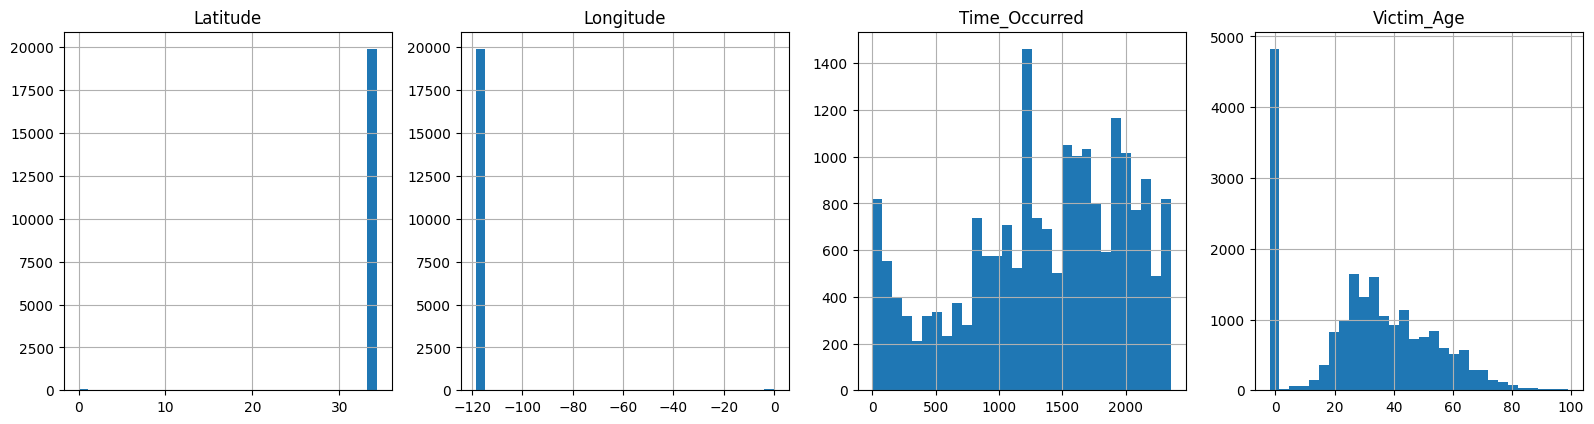

In [12]:
#Visualisation of numerical data
num_list = train[['Latitude','Longitude', 'Time_Occurred', 'Victim_Age']]
num_list.hist(bins=30, figsize=(20, 20), layout=(5, 5))
plt.tight_layout()
plt.show()

Inferences:

Latitude and Longitude shows high skewness as we alread noticed in the descriptive statistics above.

Time_Occurred distribution suggests crime incidents are higher post 12 PM compared to morning hours. Also noticeable that,there is a peak of incidents at around 12 PM. 

Victim_Age is right skewed, can suggest that most victims are young adults. However, we have seen in the desriptive statistics and from here that there are erroneous values such as negative and zero values which we have to impute.

In [13]:
#Categorical data: Descriptive Statistics
train.describe(include = ['object']).T

,count,unique,top,freq
Location,19987,12399,6TH,33
Cross_Street,3447,1495,BROADWAY,56
Date_Reported,19987,811,07/13/2020 12:00:00 AM,87
Date_Occurred,19987,366,01/01/2020 12:00:00 AM,137
Area_Name,19987,21,77th Street,1345
Modus_Operandi,17249,10489,0344,825
Victim_Sex,17365,4,M,8533
Victim_Descent,17365,17,H,6141
Premise_Description,19982,216,STREET,5028
Weapon_Description,7330,57,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",3988


Inferences:

We can see that most frequent victims of crime are Males and population from descent H.

Street(Premise_Description) is the most common premise where crime occurs.

Strong arms/use of bodily force (Weapon_Description) is the most used weapon of crime.

Looking at the Status, we can see that approximately more than 70% of the cases are still under investigation which is quite a big proportion.

From target variable, Crime_Category, we can infer that Property crimes are most frequent in the dataset.

In [14]:
#Analysing the target to check if the data is balanced
(train['Crime_Category'].value_counts())*100/len(train)

Crime_Category
Property Crimes                  58.332916
Violent Crimes                   23.825487
Crimes against Public Order       9.045880
Fraud and White-Collar Crimes     6.774403
Crimes against Persons            1.125732
Other Crimes                      0.895582
Name: count, dtype: float64

The data is imbalanced and need to take necessary steps in model training.

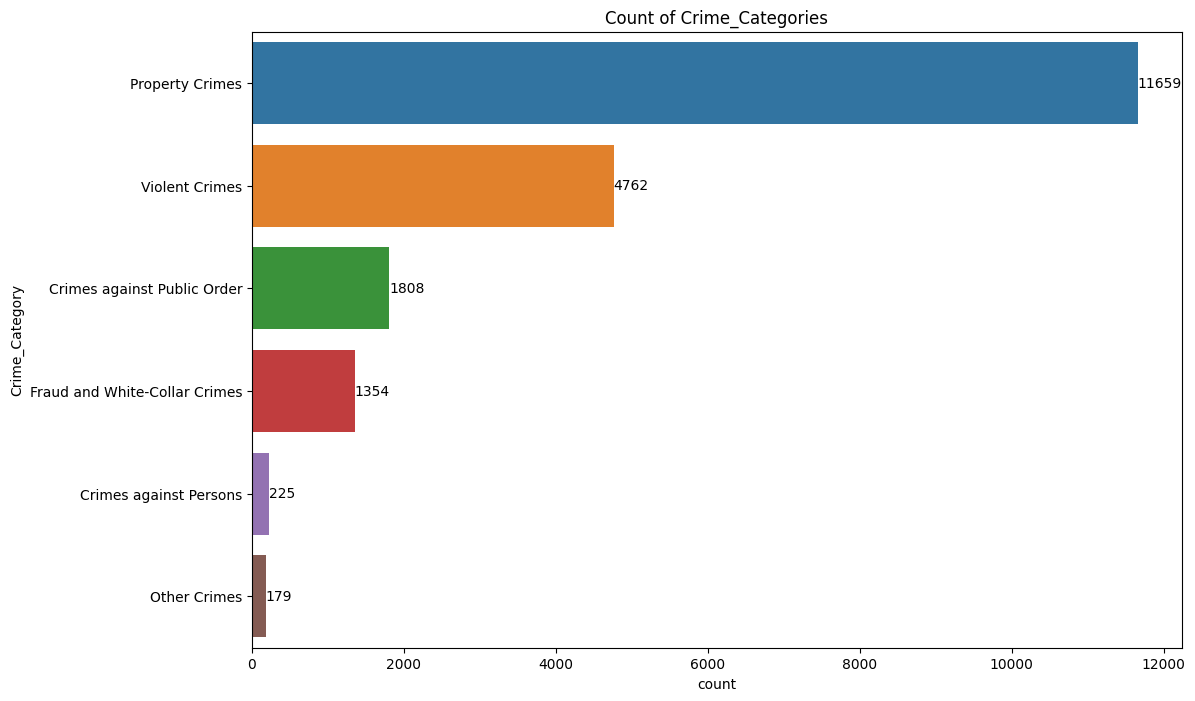

In [15]:
plt.figure(figsize=(12,8))
ax =sns.countplot(y= 'Crime_Category', data = train, order = train['Crime_Category'].value_counts().index)
ax.bar_label(ax.containers[0], fontsize=10)
plt.title('Count of Crime_Categories')
plt.show()

Based on the initial exploration of the data and the descriptive statistics, I presume that all features, except for Status and Date_Reported, could be useful for model training. This assumption is based on the observation that Status and Date_Reported are related to post-crime processes. However, further exploratory data analysis will provide more insights into the dataset.

# Where the Crime Occurred?
## Latitude & Longitude 


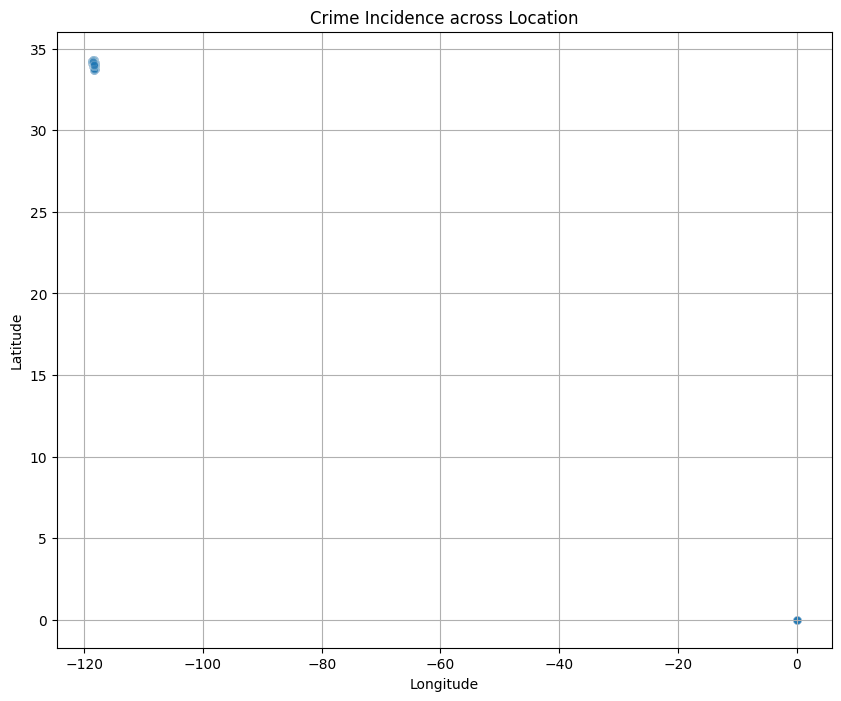

In [16]:
#identifying outliers in latitude and longitude
plt.figure(figsize = (10,8))
sns.scatterplot(x='Longitude', y='Latitude', data = train, alpha = 0.1)
plt.title('Crime Incidence across Location')
plt.grid(True)
plt.show()

We can see there are null values in the coordinates and we will have to remove them.

In [17]:
len(train.query('Latitude == 0 & Longitude == 0'))

78

In [18]:
#Removing the rows with null values
coordinate_zero_rows = (train['Latitude'] == 0) & (train['Longitude'] == 0)
train = train[~(coordinate_zero_rows)]

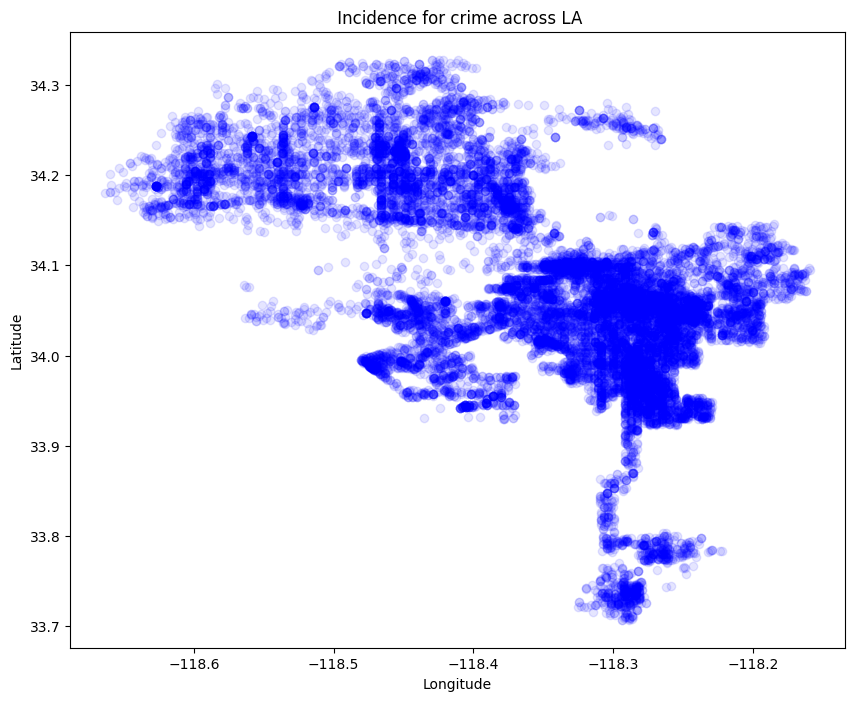

In [19]:
plt.figure(figsize= (10,8))
plt.scatter(train['Longitude'], train['Latitude'],alpha=0.1,c='blue')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(" Incidence for crime across LA")
plt.show()

To capture the spatial relationship between these coordinates, I plan to cluster the data and use the resulting cluster labels as a new feature for modeling. This approach allows the model to account for the geographic context in a more meaningful way than using the raw coordinates alone.

In [20]:
from sklearn.cluster import KMeans
X = train.loc[:,['Latitude', 'Longitude']]

/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:8

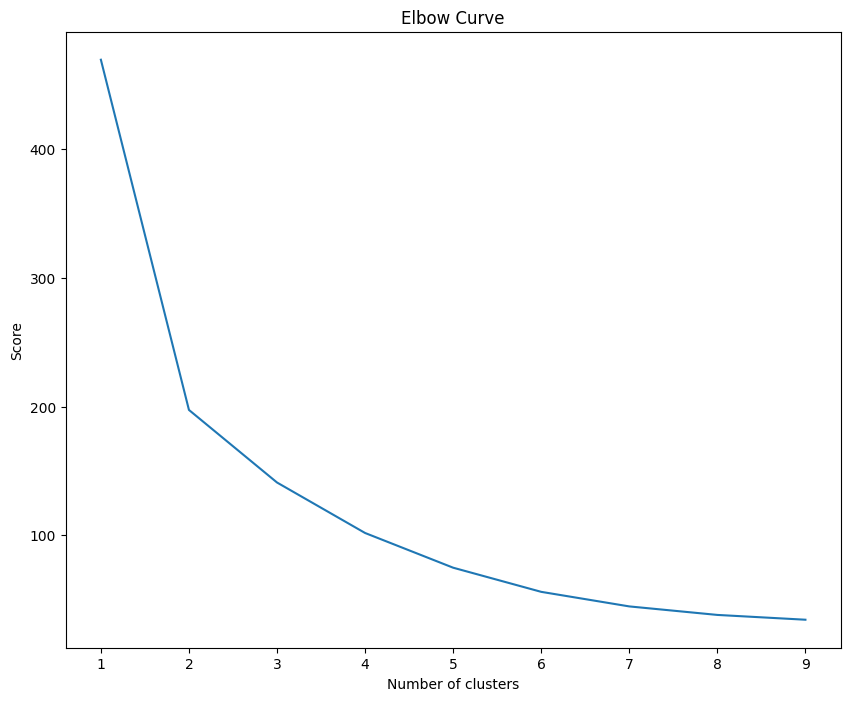

In [21]:
#finding the best K for cluster using elbow method
sse_score = {}
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k).fit(X)
    labels = kmeans.labels_
    sse_score[k] = kmeans.inertia_ 
    
plt.figure(figsize = (10,8))
plt.plot(list(sse_score.keys()), list(sse_score.values()))
plt.xlabel("Number of clusters")
plt.ylabel('Score')
plt.title('Elbow Curve')
plt.show()

The elbow is made at 3 or 4 clusters. I assume 3 is a better fit, so as to avoid more complex clustering.

In [22]:
#fitting the kmeans
kmeans = KMeans(n_clusters = 3, init ='k-means++', random_state = 42)
kmeans.fit(X) 
centers = kmeans.cluster_centers_ 
X['cluster_label'] = kmeans.labels_
X['cluster_label'].value_counts()

/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


cluster_label
0    12844
1     6151
2      914
Name: count, dtype: int64

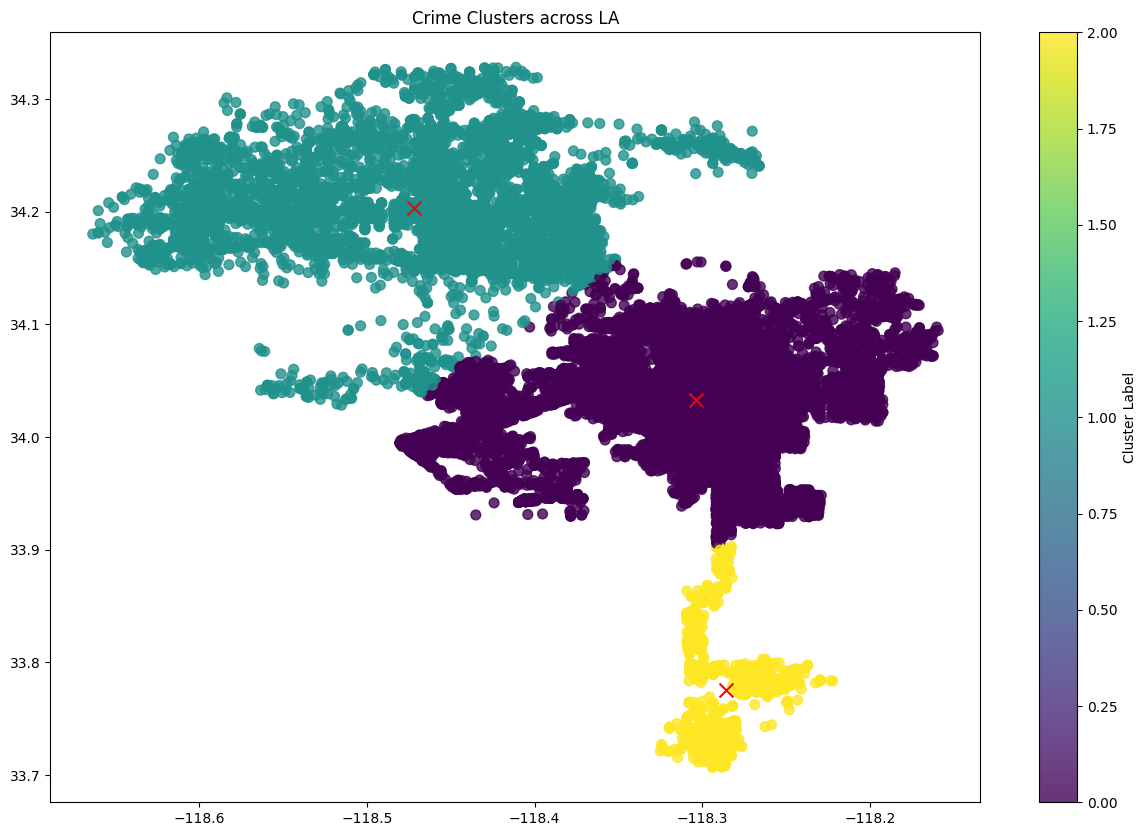

In [23]:
centers = kmeans.cluster_centers_

vmin, vmax = X['cluster_label'].min(), X['cluster_label'].max()

plt.figure(figsize=(15, 10))
sc =plt.scatter(x='Longitude', y='Latitude', c='cluster_label', data=X, s=50, cmap='viridis', vmin=vmin, vmax=vmax,alpha =0.8)

plt.scatter(centers[:, 1], centers[:, 0], c='red', marker='x', s=100)

plt.colorbar(sc, label='Cluster Label')
plt.title("Crime Clusters across LA")
plt.show()

In [24]:
#Adding the feature cluster label to train data
train = pd.concat([train, X[['cluster_label']]], axis =1)

<Figure size 2000x2000 with 0 Axes>

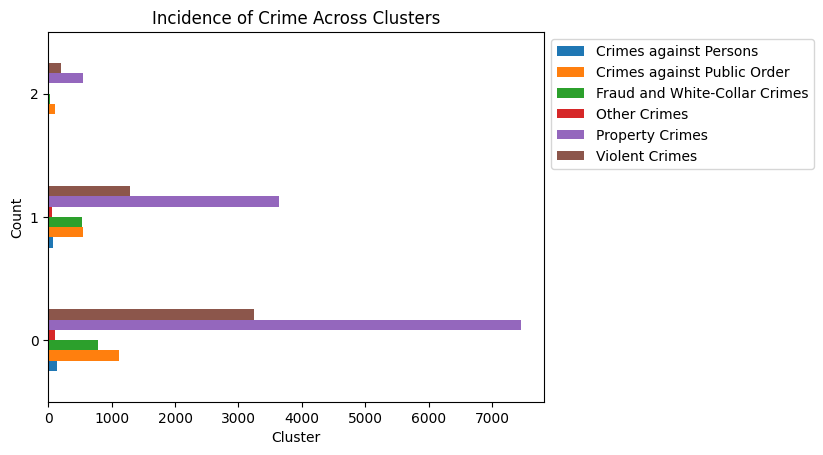

In [25]:
plt.figure(figsize = (20,20))
clustervscrime = pd.crosstab(train['cluster_label'], train['Crime_Category'])
clustervscrime.plot(kind = 'barh')
plt.xlabel("Cluster")
plt.ylabel('Count')
plt.title('Incidence of Crime Across Clusters')
plt.legend(bbox_to_anchor = (1,1), loc ='upper left')
plt.show()

In [26]:
clustervscrime = pd.crosstab(train['cluster_label'], train['Crime_Category'], normalize = 'index')*100
clustervscrime

Crime_Category,Crimes against Persons,Crimes against Public Order,Fraud and White-Collar Crimes,Other Crimes,Property Crimes,Violent Crimes
cluster_label,,,,,,
0,1.051074,8.720025,6.119589,0.856431,57.972594,25.280287
1,1.170541,9.039181,8.681515,0.975451,59.112339,21.020972
2,1.969365,12.144420,3.391685,0.547046,60.065646,21.881838


Property Crimes is in high proportion in all clusters and cluster 2 has highest proportion of Property Crimes.

Cluster 0 has high proportion of violent crimes compared to other clusters.

Fraud and White-Collar Crimes have a higher proportion in Cluster 1, indicating that this cluster might be more associated with economic criminal activities.

Crimes against Public Order and Crimes against Persons are more prevalent in Cluster 2 compared to the other clusters.

The differences in crime concentration among clusters can owe to other factors such as population density, police enforcement, socio-economics features like poverty, income and standard of living, size of clusters. 

## Area_ID & Area_Name

In [27]:
#Area_ID, checking value_counts()
train['Area_ID'].value_counts().sort_values()

Area_ID
16.0     731
4.0      751
17.0     766
10.0     790
21.0     790
11.0     838
19.0     865
5.0      871
9.0      901
8.0      910
2.0      924
7.0      932
20.0     953
13.0     995
6.0     1004
15.0    1061
18.0    1062
3.0     1127
14.0    1149
1.0     1151
12.0    1338
Name: count, dtype: int64

Area_ID has values ranging from 1 to 21, with certain Area Divisions having higher incidents of crime. If we see the feature Area_Name we can infer the names of each Area ID and check for the top crime prone area and bottom

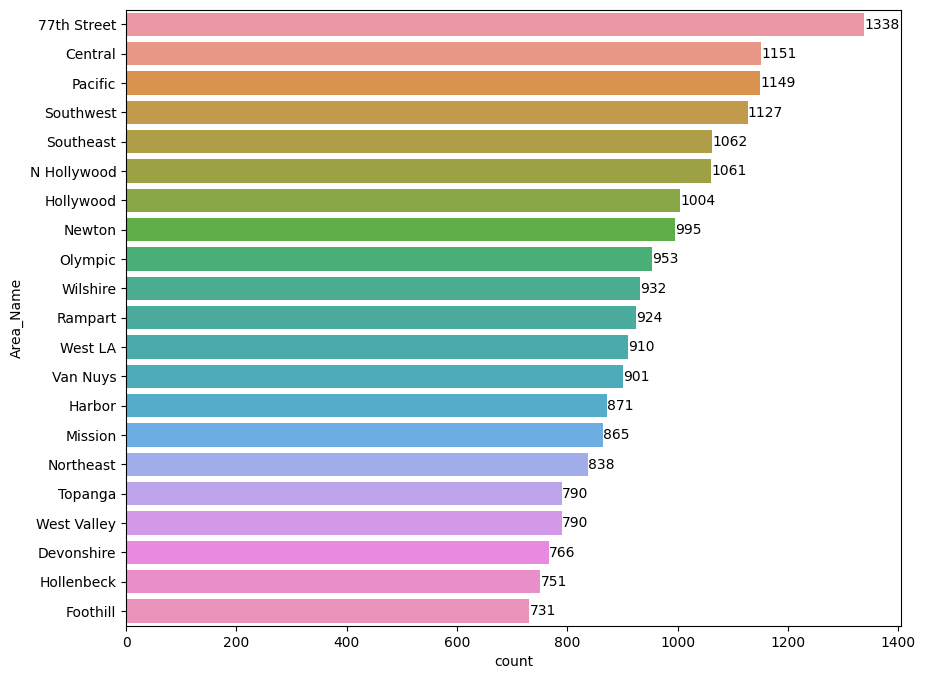

In [28]:
plt.figure(figsize=(10,8))
ax = sns.countplot(data = train, y = 'Area_Name', order = train['Area_Name'].value_counts().index)
ax.bar_label(ax.containers[0], fontsize=10)
plt.show()

77th Street has the highest number of crimes. We can try plotting this information to get a better picture where these areas are placed.

/tmp/ipykernel_17/2049920728.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('coolwarm')
/tmp/ipykernel_17/2049920728.py:31: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = plt.colorbar(sm)


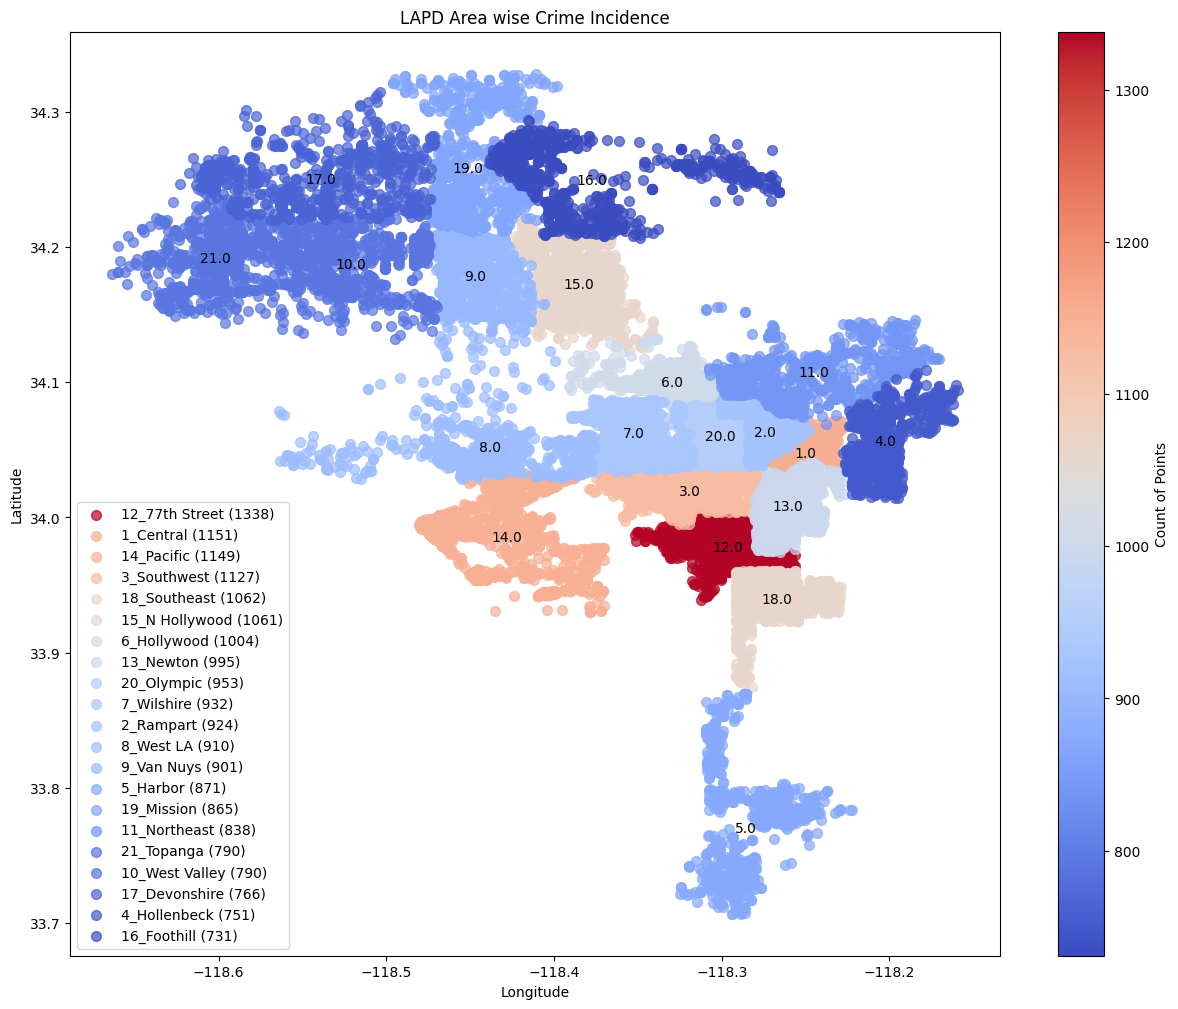

In [29]:
train_c = train.copy()
train_c['Area_Name']= train_c['Area_ID'].astype(int).astype(str)+ '_' + train_c['Area_Name']

Area_Name_counts = train_c['Area_Name'].value_counts()

# Normalizing area counts for color map
norm = Normalize(vmin=Area_Name_counts.min(), vmax=Area_Name_counts.max())

cmap = cm.get_cmap('coolwarm')

color_mapping = {area: cmap(norm(count)) for area, count in Area_Name_counts.items()}

fig, ax = plt.subplots(figsize=(15, 12))

for area in Area_Name_counts.index:
    subset = train_c[train_c['Area_Name'] == area]
    color = color_mapping[area]
    ax.scatter(subset['Longitude'], subset['Latitude'], color=color, label=f"{area} ({Area_Name_counts[area]})", s=50, alpha=0.7)

     # Calculate the centroid of the points to annotate
    centroid_lon = subset['Longitude'].mean()
    centroid_lat = subset['Latitude'].mean()

    # Annotate the map with Area_ID at the centroid
    area_id = train_c.loc[train_c['Area_Name'] == area, 'Area_ID'].iloc[0]
    ax.annotate(str(area_id), (centroid_lon, centroid_lat), color='black', fontsize=10, ha='center', va='center')

#Colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm)
cbar.set_label('Count of Points')

plt.title('LAPD Area wise Crime Incidence')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.show()

The 77th Street Area Division (Area_ID = 12) has the highest crime rate, while Foothill (Area_ID = 16) is the safest. Crime rates are notably higher in Area Divisions located in the central region, with adjacent districts to the 77th Street Area also experiencing a high incidence of crime, each within a range of 1,000 incidents. These neighboring divisions rank among the top four crime-prone areas.

In contrast, most areas in the northern and southern regions experience lower crime rates compared to the central region, as observed when analyzing crime clusters.

Two key inferences can be drawn: First, many of the most crime-prone Area Divisions are located adjacent to each other, and similarly, the least crime-prone divisions are also clustered together geographically. If we had access to population density data or other socio-economic factors, we could further investigate why certain areas experience higher crime rates.

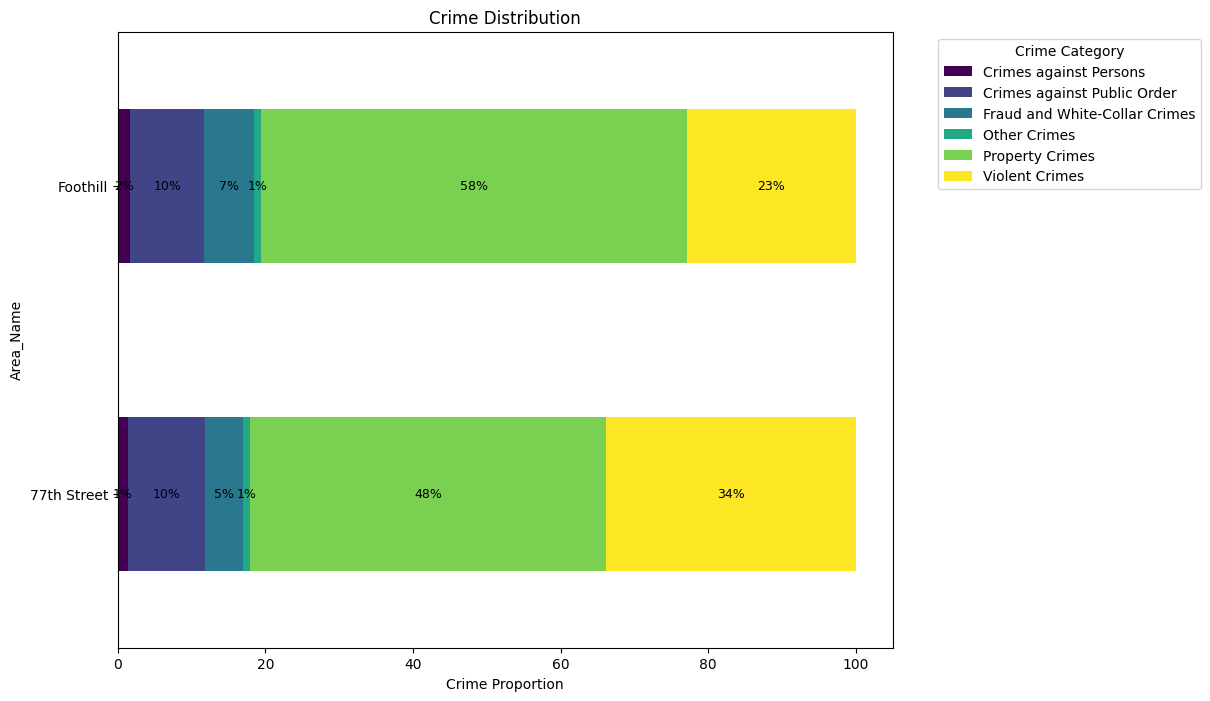

In [30]:
area_top_bottom = train[train['Area_Name'].isin(['77th Street', 'Foothill'])]
area_top_bottom= pd.crosstab(area_top_bottom ['Area_Name'], area_top_bottom['Crime_Category'], normalize = 'index')*100
ax = area_top_bottom.plot(kind='barh', stacked=True, figsize=(10, 8), colormap='viridis')

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.text(x+width/2,
            y+height/2,
            '{:.0f}%'.format(width),
            horizontalalignment='center',
            verticalalignment='center',
            color='black',
            fontsize=9)

# Add labels and title
plt.xlabel('Crime Proportion')
plt.ylabel('Area_Name')
plt.title('Crime Distribution')
plt.legend(title='Crime Category')
plt.legend(title='Crime Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

Even though, crime volume is different in both Area Divisions, the proportion of different crimes in total is almost similar. Foothill has more of Property Crimes and Fraud and white collar crimes. 77th Street has high proportion of Violent Crimes. This is in line with what we explored with cluster analysis. 

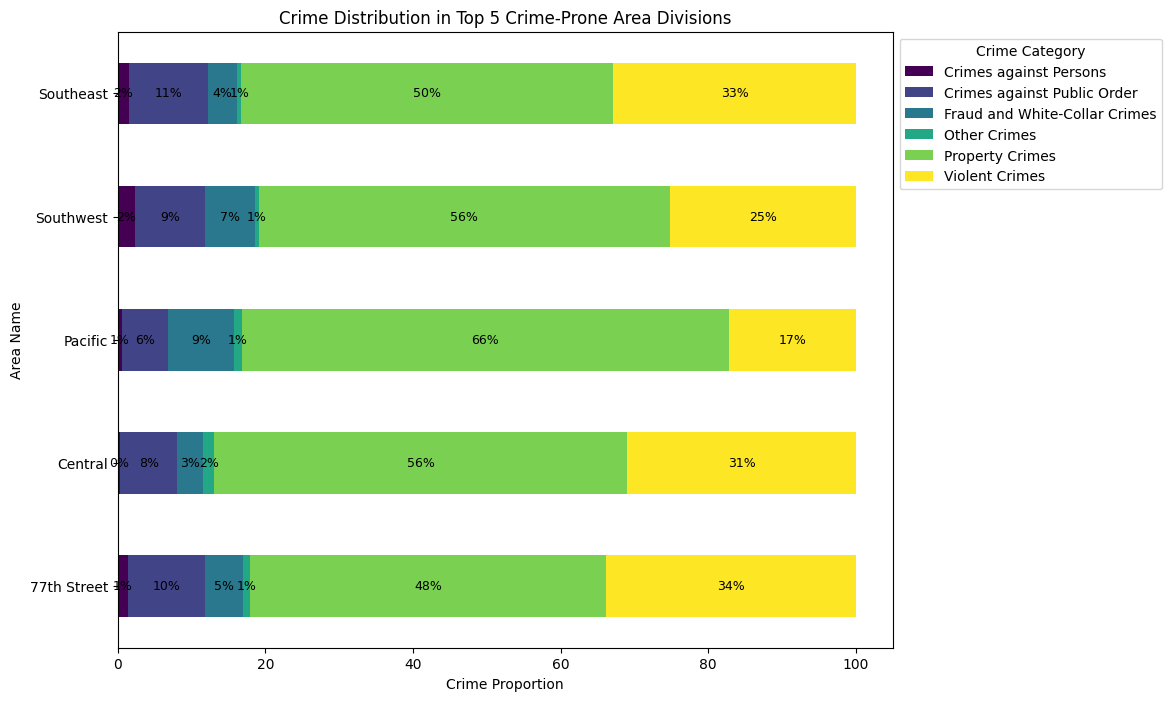

In [31]:
top5_crimeindex = train['Area_Name'].value_counts().head(5).index
top5_crime_data = train[train['Area_Name'].isin(top5_crimeindex)]
Top5_pivot = (
    top5_crime_data.pivot_table(index='Area_Name',
                                columns='Crime_Category', 
                                aggfunc='size', fill_value=0))
Top5_pivot = Top5_pivot.loc[Top5_pivot.sum(axis=1).sort_values(
    ascending=False).index].pipe(lambda df: (df.T / df.sum(axis=1)).T * 100)

# Plotting the stacked bar graph
ax = Top5_pivot.plot(kind='barh', stacked=True, figsize=(10, 8), colormap='viridis')

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.text(x+width/2,
            y+height/2,
            '{:.0f}%'.format(width),
            horizontalalignment='center',
            verticalalignment='center',
            color='black',
            fontsize=9)

plt.title('Crime Distribution in Top 5 Crime-Prone Area Divisions')
plt.xlabel('Crime Proportion')
plt.ylabel('Area Name')
plt.legend(title='Crime Category', bbox_to_anchor=(1, 1))
plt.show()

Proportions of different crimes are varying across top 5 area divisions. All these top 5 Area Divisons are also close by geographically.

## Reporting District No.

In [32]:
train.groupby(by = ['Area_ID', 'Reporting_District_no']).size()

Area_ID  Reporting_District_no
1.0      101.0                    17
         105.0                     6
         111.0                    68
         112.0                     3
         118.0                    20
                                  ..
21.0     2185.0                   16
         2187.0                   36
         2189.0                   37
         2196.0                    9
         2197.0                    3
Length: 1120, dtype: int64

Reporting_District_no. provides information on crime prevalence in sub-divisions of Area Divisions. This feature gives more granular information on distribution of crime than Area ID feature. We will have to drop any one of them in model training to avoid redundancy. 

In [33]:
 train.groupby(['Area_ID', 'Reporting_District_no']).size().sort_values(ascending=False).head(10)

Area_ID  Reporting_District_no
6.0      645.0                    99
1.0      162.0                    85
         182.0                    72
18.0     1822.0                   72
14.0     1494.0                   71
3.0      363.0                    69
14.0     1431.0                   69
1.0      111.0                    68
12.0     1239.0                   68
18.0     1802.0                   67
dtype: int64

Reporting District 645 in Area Division Hollywood (Area_ID = 6) is the highest crime prone district among the districts in LA. There are some district with very less crimes. It could be that data was not collected or those areas have strict law and order enforcement. We can check the different crimes in top 10 crime prone districts.

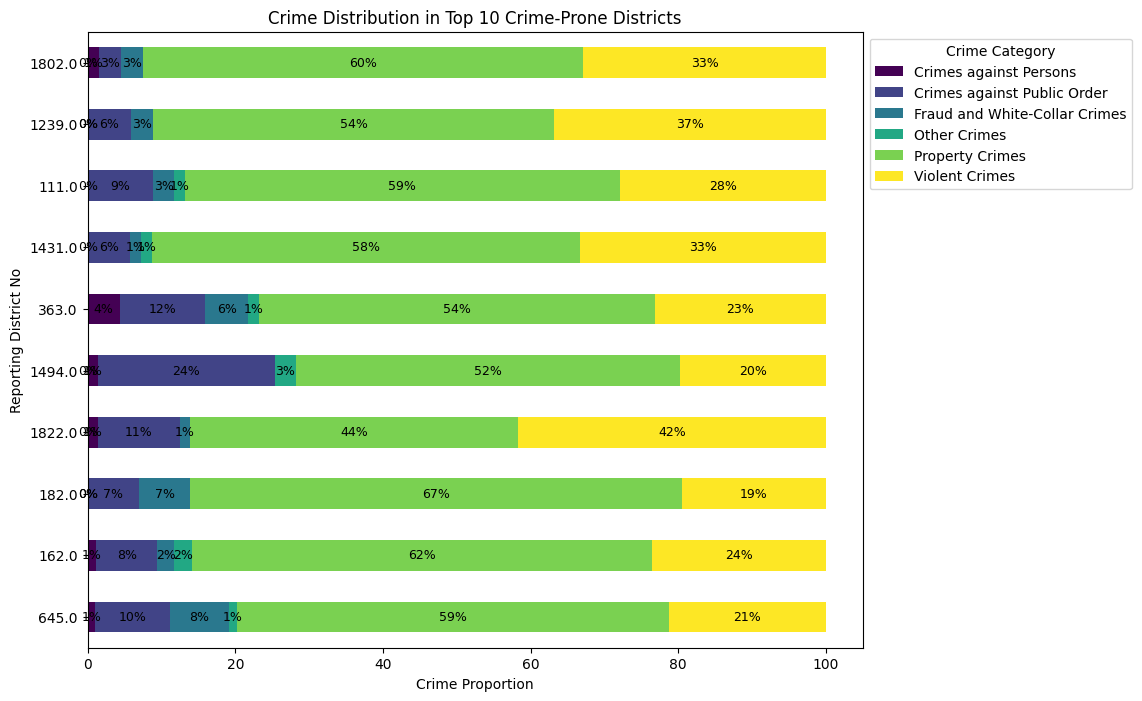

In [34]:
top10_districts_index = train['Reporting_District_no'].value_counts().head(10).index
top10_districts = train[train['Reporting_District_no'].isin(top10_districts_index)]

Top10_pivot = (
    top10_districts.pivot_table(index='Reporting_District_no', 
                                columns='Crime_Category', aggfunc='size', fill_value=0))
Top10_pivot = Top10_pivot.loc[Top10_pivot.sum(axis=1).sort_values(
    ascending=False).index].pipe(lambda df: (df.T / df.sum(axis=1)).T * 100)

ax = Top10_pivot.plot(kind='barh', stacked=True, figsize=(10, 8), colormap='viridis')

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.text(x+width/2,
            y+height/2,
            '{:.0f}%'.format(width),
            horizontalalignment='center',
            verticalalignment='center',
            color='black',
            fontsize=9)

plt.title('Crime Distribution in Top 10 Crime-Prone Districts')
plt.xlabel('Crime Proportion')
plt.ylabel('Reporting District No')
plt.legend(title='Crime Category', bbox_to_anchor=(1, 1), loc='upper left')
plt.show()

As we can see the proportion of different crime categories across districts varies. There are districts with no counts of Other crimes.

## Location & Cross_Street

I will be dropping the feature Cross_Street because it has around 80 % missing values.

In [35]:
train = train.drop('Cross_Street', axis =1)

In [36]:
print(train['Location'].unique())

['4500    CARPENTER                    AV'
 '45TH                         ST'
 '600 E  MARTIN LUTHER KING JR        BL' ...
 '15800    STRATHERN                    ST'
 '5100 W  ADAMS                        BL'
 'DALTON                       AV']


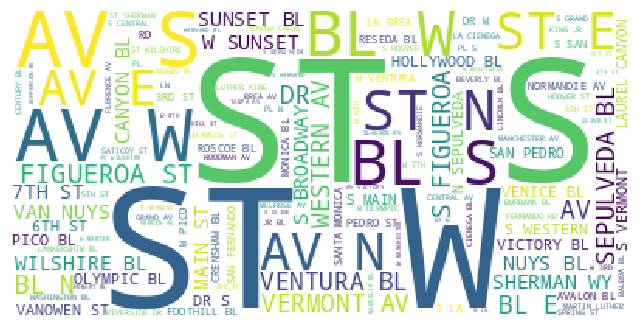

In [37]:
#Making a wordcloud
text = " ".join(address for address in train['Location'])
stopwords = set(STOPWORDS)

wordcloud = WordCloud(stopwords = stopwords, background_color = 'White').generate(text)

plt.figure(figsize = (8,6))
plt.imshow(wordcloud, interpolation = 'nearest')
plt.axis('off')
plt.show()

I can see that street type suffixes such as ST, AV, BL etc. are very evident in the wordcloud. Address data is highly variable and high-dimensional. Extracting the street type simplifies this information, making it more manageable and less sparse. However, this may lead to considerable information loss. My reasoning for choosing street type suffixes is, one, I can see that almost all rows have street type suffixes. Two, different street types may be associated with different types of environments (e.g "ST" a commercial area, "AV" for urban complex), which could correlate with the types of crimes occurring there.

In [38]:
location_address = pd.DataFrame(train['Location'])
street_types = {
    'STREET': 'ST',
    'ST': 'ST',
    'AVENUE': 'AV',
    'AVE': 'AV',
    'AV': 'AV',
    'ALLEY':'ALLEY',
    'ALY':'ALY',
    'BOULEVARD': 'BL',
    'BLVD': 'BL',
    'BL': 'BL',
    'DRIVE': 'DR',
    'DR': 'DR',
    'ROAD': 'RD',
    'RD': 'RD',
    'COURT': 'CT',
    'CT': 'CT',
    'CTS':'CTS',
    'LANE': 'LN',
    'LN': 'LN',
    'CIRCLE': 'CIR',
    'CIR': 'CIR',
    'PLACE': 'PL',
    'PL': 'PL',
    'PARKWAY': 'PKWY',
    'PKWY': 'PKWY',
    'TERRACE': 'TER',
    'TER': 'TER',
    'WAY': 'WY',
    'WY':'WY',
    'ARC':'ARC',
}

def extract_street_type(address):
    address = address.upper()#capitalize
    for full, abbr in street_types.items():
        if re.search(r'\b' + full + r'\b', address):
            address = re.sub(r'\b' + full + r'\b', abbr, address)
            return abbr
    return None

location_address['Street_Type'] = location_address['Location'].apply(extract_street_type)
(location_address['Street_Type'].value_counts(dropna=False)/len(train))*100

Street_Type
ST      33.025265
AV      29.333467
BL      18.579537
None     8.935657
DR       3.907780
PL       2.727410
WY       1.642473
RD       1.235622
LN       0.346577
CT       0.210960
CIR      0.045206
TER      0.005023
PKWY     0.005023
Name: count, dtype: float64

Street (ST), Avenues(AV) and Boulevard(BL) are the most crime prone street types. I will bin those street types with less than 1% proportion into category 'Others'

In [39]:
# Prominent street types
main_street_types = ['ST', 'AV', 'BL', 'DR', 'PL','WY','RD']
# Binning the less common street types into "Others"
location_address['Street_Type_bin'] = location_address['Street_Type'].apply(
    lambda x: x if x in main_street_types else ('Others' if x is not None else None)
)

street_type_counts = location_address['Street_Type_bin'].value_counts(dropna = False)
print(street_type_counts)


Street_Type_bin
ST        6575
AV        5840
BL        3699
None      1779
DR         778
PL         543
WY         327
RD         246
Others     122
Name: count, dtype: int64


There are 1779 rows with street type suffixes missing, which I will impute in data preprocessing.

In [40]:
train = pd.concat([train, location_address[['Street_Type_bin']]], axis =1)

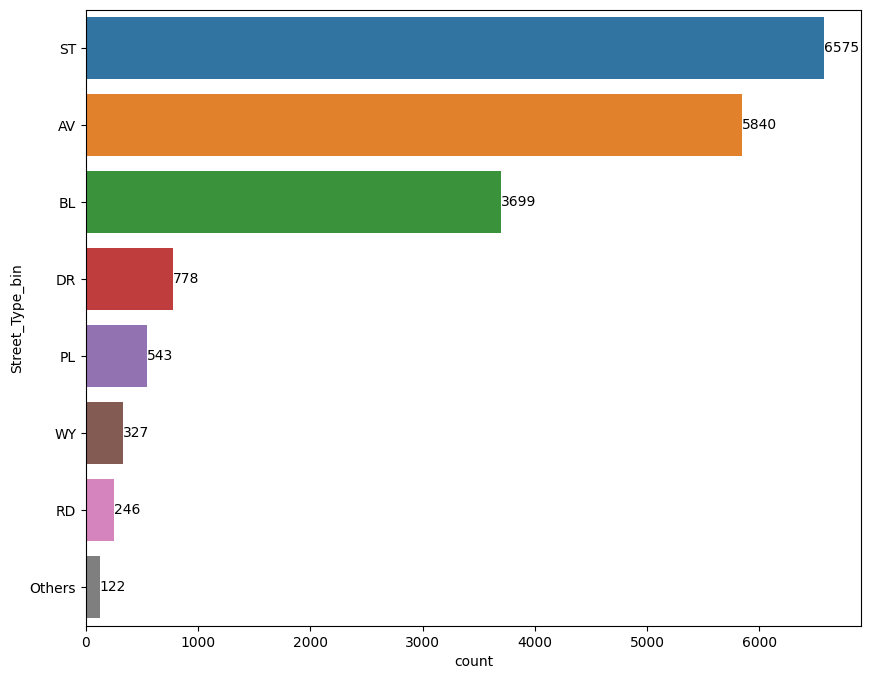

In [41]:
plt.figure(figsize=(10,8))
ax = sns.countplot(data = train, y = 'Street_Type_bin', 
                   order = train['Street_Type_bin'].value_counts().index)
ax.bar_label(ax.containers[0], fontsize=10)
plt.show()

In [42]:
streetvscrime = pd.crosstab(train['Street_Type_bin'], train['Crime_Category'], normalize = 'index')
streetvscrime

Crime_Category,Crimes against Persons,Crimes against Public Order,Fraud and White-Collar Crimes,Other Crimes,Property Crimes,Violent Crimes
Street_Type_bin,,,,,,
AV,0.012500,0.090411,0.078082,0.007534,0.593664,0.217808
BL,0.007570,0.077589,0.065964,0.008110,0.628278,0.212490
DR,0.008997,0.093830,0.110540,0.008997,0.633676,0.143959
Others,0.024590,0.122951,0.172131,0.000000,0.500000,0.180328
PL,0.016575,0.116022,0.071823,0.016575,0.534070,0.244936
RD,0.016260,0.085366,0.109756,0.016260,0.581301,0.191057
ST,0.013840,0.097490,0.063726,0.007909,0.551483,0.265551
WY,0.015291,0.122324,0.051988,0.015291,0.581040,0.214067


Link: https://pw.lacounty.gov/services/roads/streetname/policy.pdf, I referred this document to understand how are street suffixes assigned. ST, according to document is a street which facilitates movement and connects various areas for both pedestrians and vehicles. And it is noticeable that ST has high proportion of violent crimes. 

## Premise Code & Premise Description

In [43]:
train['Premise_Description'].nunique()

216

There's 216 unique premises in the dataset. We will see the top 10 premises and their crime distribution.

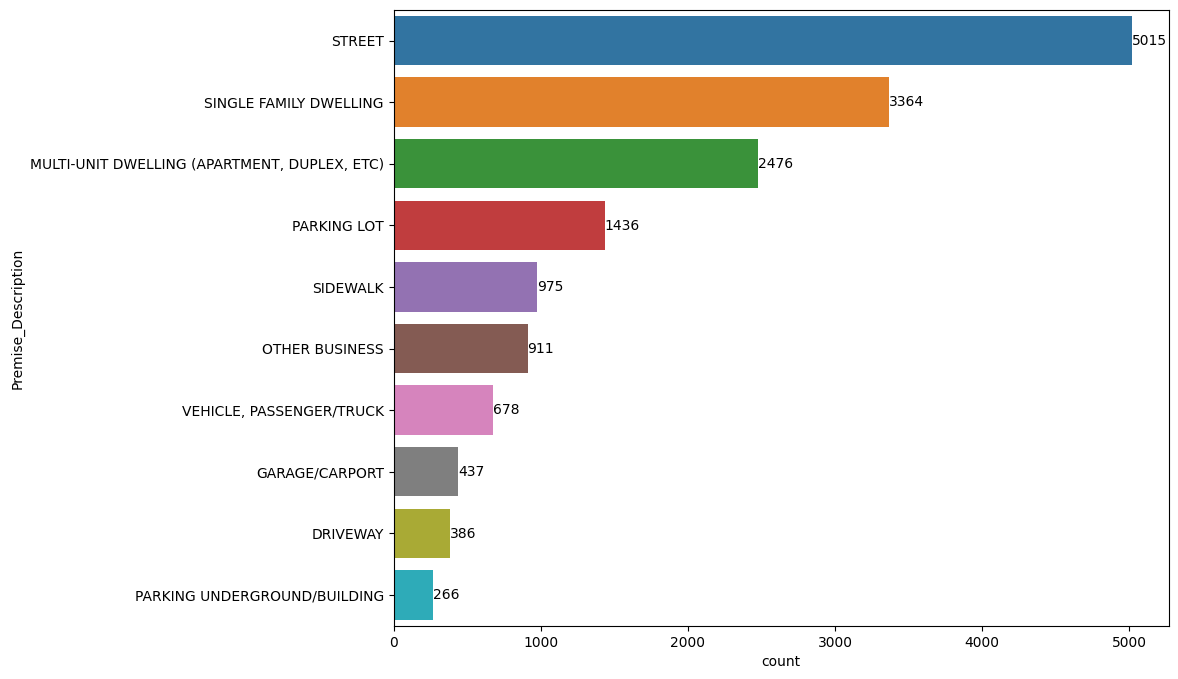

In [44]:
plt.figure(figsize =(10,8))
count = train['Premise_Description'].value_counts().head(10).index
ax = sns.countplot(y = 'Premise_Description', data = train, order = count)
ax.bar_label(ax.containers[0], fontsize=10)
plt.show()

There are many premises with very less occurences. For the purpose of reducing complexity, I will bin these premises into other category.

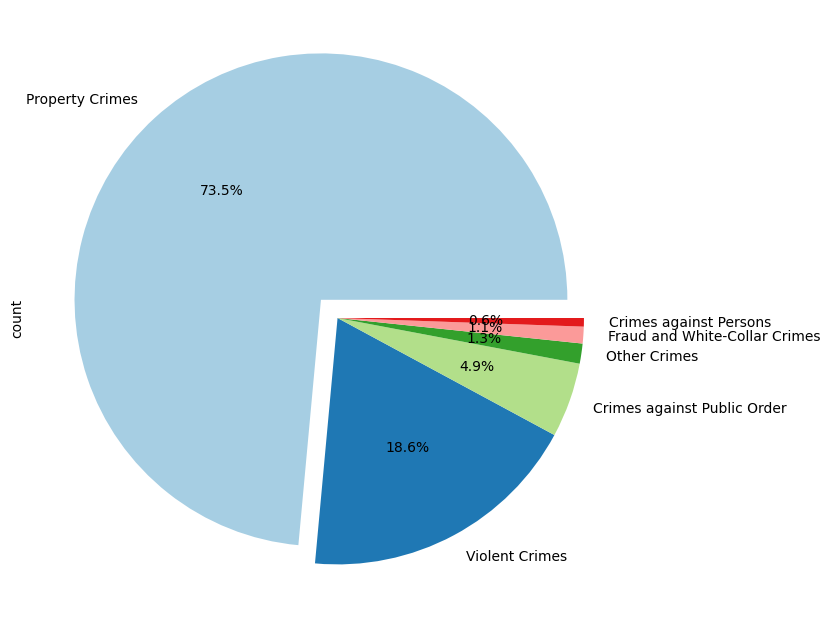

In [45]:
explode = (0.1,0, 0, 0,0,0) 
top_premise = train[train['Premise_Description'] == 'STREET']
crime_counts = top_premise['Crime_Category'].value_counts()
plt.figure(figsize=(8, 8))
crime_counts.plot(kind='pie', explode = explode, autopct='%1.1f%%', 
                  colors=plt.cm.Paired(range(len(crime_counts))))
plt.show()

Again Property crimes are in high proportion followed by violent crimes. Since Single family dewelling and multi-unit dewelling are both residential units, I will see if the crime distribution is similar in both.

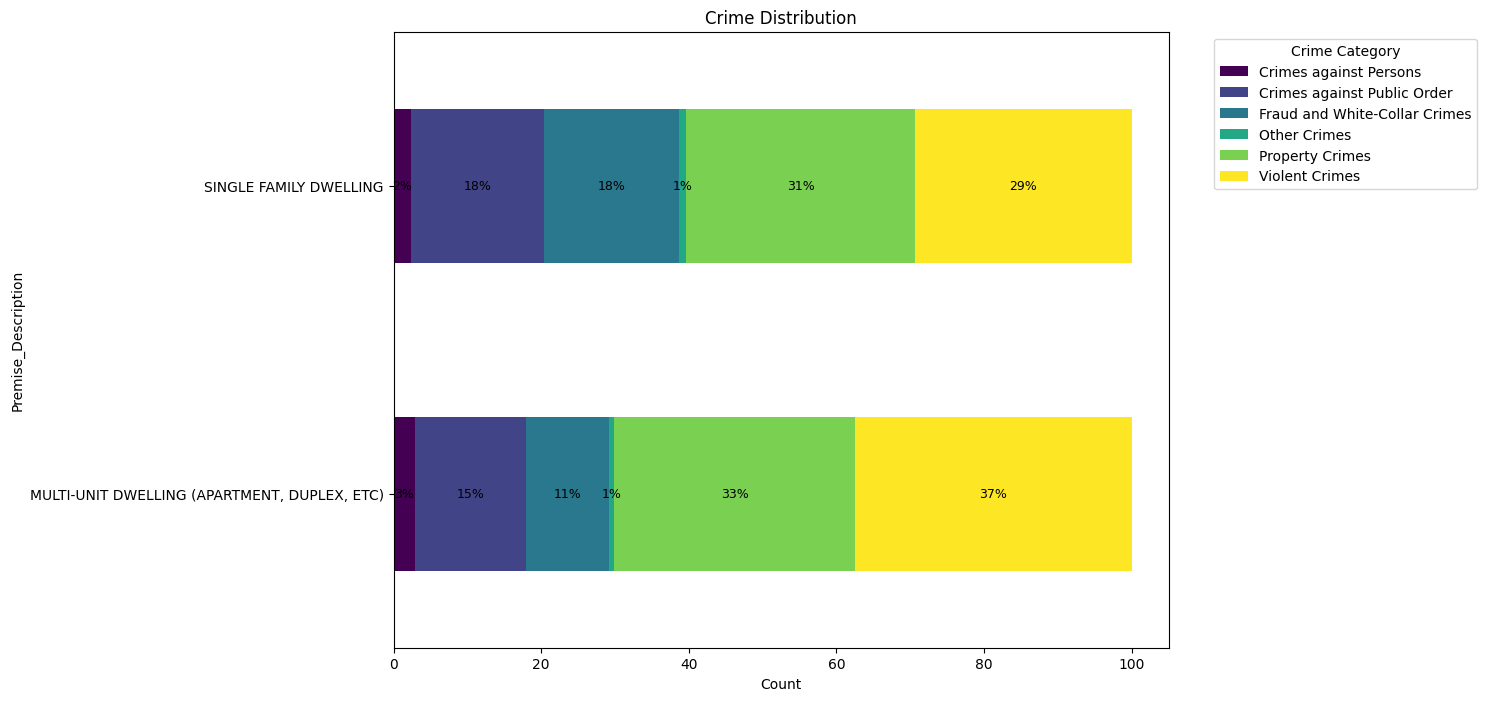

In [46]:
premise_residence = train[train['Premise_Description'].isin(['SINGLE FAMILY DWELLING',
                                                             'MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)'])]
premise_residence= pd.crosstab(premise_residence['Premise_Description'],
                               premise_residence['Crime_Category'], normalize = 'index')*100
ax = premise_residence.plot(kind='barh', stacked=True, figsize=(10, 8), colormap='viridis')

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.text(x+width/2,
            y+height/2,
            '{:.0f}%'.format(width),
            horizontalalignment='center',
            verticalalignment='center',
            color='black',
            fontsize=9)

# Add labels and title
plt.xlabel('Count')
plt.ylabel('Premise_Description')
plt.title('Crime Distribution')
plt.legend(title='Crime Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [47]:
Top_Premise = train['Premise_Code'].value_counts(dropna=True)
Top_Premise = Top_Premise[Top_Premise > 200].index
train['Premise_Code'] = train['Premise_Code'].apply(
    lambda x: x if x in Top_Premise else ('Others' if not pd.isna(x) else np.nan)
)
train['Premise_Code'].value_counts(dropna=False)

Premise_Code
101.0     5015
Others    3740
501.0     3364
502.0     2476
108.0     1436
102.0      975
203.0      911
122.0      678
707.0      437
104.0      386
123.0      266
210.0      225
Name: count, dtype: int64

# Who was the victim?
## Victim Sex

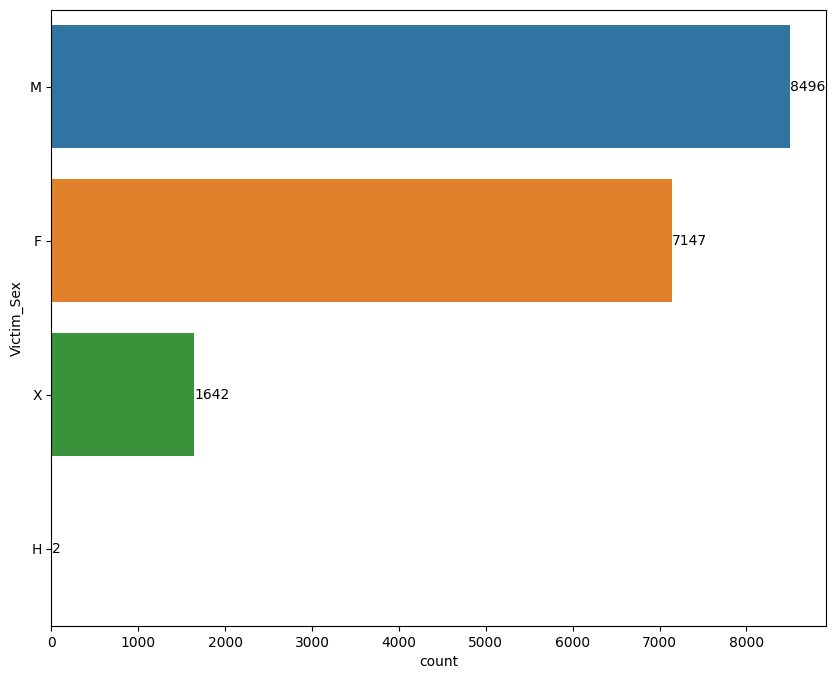

In [48]:
plt.figure(figsize = (10,8))
ax = sns.countplot(y = train['Victim_Sex'], order= train['Victim_Sex'].value_counts().index)
ax.bar_label(ax.containers[0], fontsize=10)
plt.show()

Males are the most frequent victims of crime. I am assuming X is unknown. H has just two observations which is very less to make it an another category. It could be a data entry error, I am going to replace it as NaN.

In [49]:
train[train['Victim_Sex']=='H']

,Location,Latitude,Longitude,Date_Reported,Date_Occurred,Time_Occurred,Area_ID,Area_Name,Reporting_District_no,Part 1-2,...,Victim_Descent,Premise_Code,Premise_Description,Weapon_Used_Code,Weapon_Description,Status,Status_Description,Crime_Category,cluster_label,Street_Type_bin
4970,1500 E 112TH ST,33.9332,-118.2485,05/18/2020 12:00:00 AM,05/17/2020 12:00:00 AM,1630.0,18.0,Southeast,1846.0,2.0,...,B,502.0,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",NaN,NaN,IC,Invest Cont,Fraud and White-Collar Crimes,0,ST
16290,1600 W 2ND ST,34.0613,-118.2638,01/03/2020 12:00:00 AM,01/03/2020 12:00:00 AM,2200.0,2.0,Rampart,237.0,2.0,...,F,Others,ALLEY,NaN,NaN,IC,Invest Cont,Property Crimes,0,ST


In [50]:
train['Victim_Sex'] = train['Victim_Sex'].replace('H',np.nan)

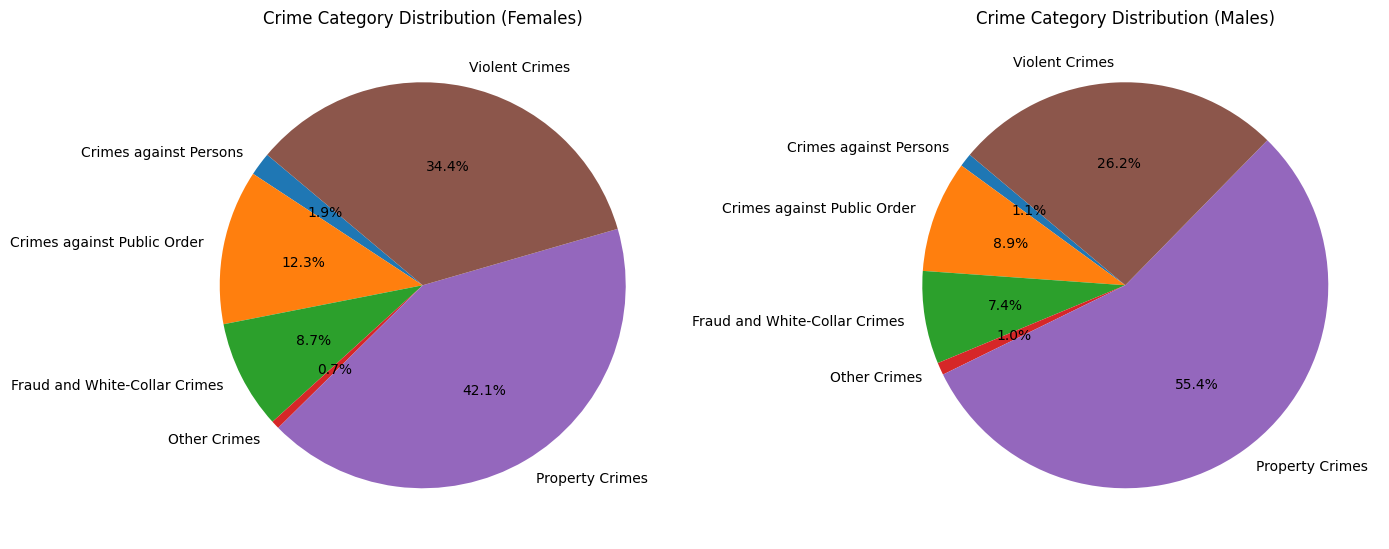

In [51]:
gender_crime_distribution = train.groupby(['Victim_Sex', 'Crime_Category']).size().unstack(fill_value=0)

female_counts = gender_crime_distribution.loc['F']
male_counts = gender_crime_distribution.loc['M']

fig, axs = plt.subplots(1, 2, figsize=(14, 7))

#Female pie plot
axs[0].pie(female_counts, labels=female_counts.index, autopct='%1.1f%%', startangle=140)
axs[0].set_title('Crime Category Distribution (Females)')

# Male pie plot
axs[1].pie(male_counts, labels=male_counts.index, autopct='%1.1f%%', startangle=140)
axs[1].set_title('Crime Category Distribution (Males)')


plt.tight_layout()
plt.show()


Compared to male victims, feemales victims are seen to have lower proportions of crimes for Other Crimes and Property Crimes. Something to check is where are females mostly effected, which premises?

In [52]:
premisevsgender = pd.crosstab(train['Premise_Description'], train['Victim_Sex'])
top_premises = premisevsgender.sum(axis=1).sort_values(ascending=False).head(10).index
top_premises_crosstab = premisevsgender.loc[top_premises]
top_premises_crosstab

Victim_Sex,F,M,X
Premise_Description,,,
SINGLE FAMILY DWELLING,1927,1409,27
STREET,1131,1803,162
"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",1387,988,99
PARKING LOT,378,609,67
SIDEWALK,349,584,42
OTHER BUSINESS,177,379,320
"VEHICLE, PASSENGER/TRUCK",308,340,30
GARAGE/CARPORT,128,201,12
DRIVEWAY,114,165,2


<Figure size 2000x2000 with 0 Axes>

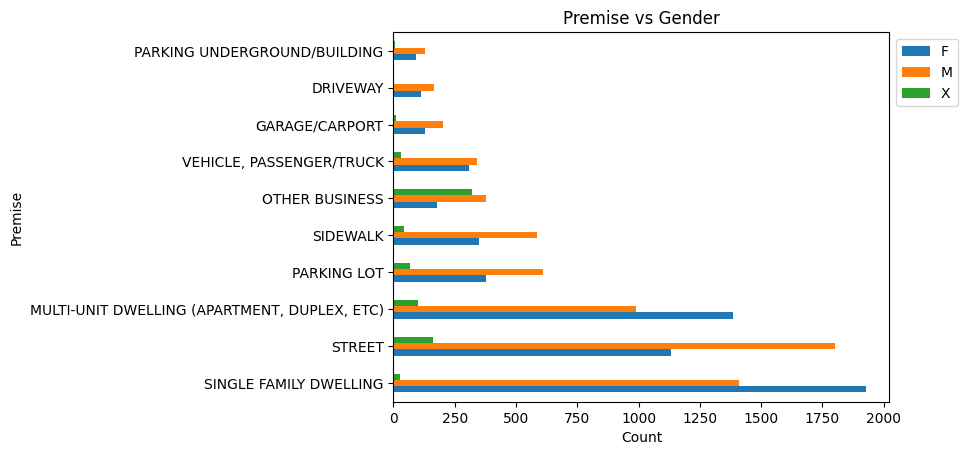

In [53]:
plt.figure(figsize = (20,20))
top_premises_crosstab.plot(kind = 'barh')
plt.xlabel("Count")
plt.ylabel('Premise')
plt.title('Premise vs Gender')
plt.legend(bbox_to_anchor = (1,1), loc ='upper left')
plt.show()

The volume of crime against Females are higher in single family dewelling and multi-unit dewelling, which are basically residential property or aparments. This is indicates Females are subjected to crime more within their households. While Males are seen to become victims more on the streets, parking lots, sidewalks and other places outside a household.

Which Area Division is safer for females and males?

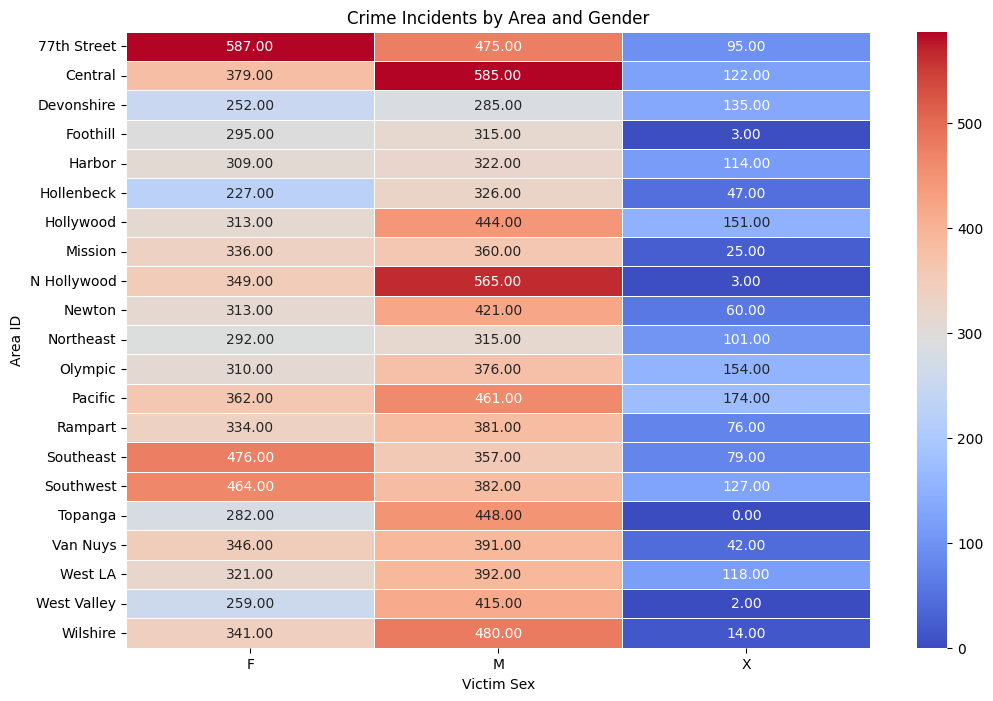

In [54]:
areavssex = pd.crosstab(train['Area_Name'], train['Victim_Sex'])
plt.figure(figsize=(12, 8))
sns.heatmap(areavssex, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Crime Incidents by Area and Gender')
plt.xlabel('Victim Sex')
plt.ylabel('Area ID')
plt.show()

77th Street is the highest crime prone Area Division, both females and males are highly targeted in this Area Division. This division also has the highest female victim targets. In North Hollywood(N Hollywood), Males are highly prone to crime incidence. Area Divisions such as Hollenback, Devonshire, Topanga and West valley have lesser female targets. These regions may have lesser domestic violence? 

While in contrast, in some of these regions Males are highly targeted. Overall, almost across all areas, males are targeted more than females.

## Victim_Age

First we will clean the data for visualization. There are some erroneous values in age.

In [55]:
train['Victim_Age'] = train['Victim_Age'].replace([-1,-2,0],np.nan)

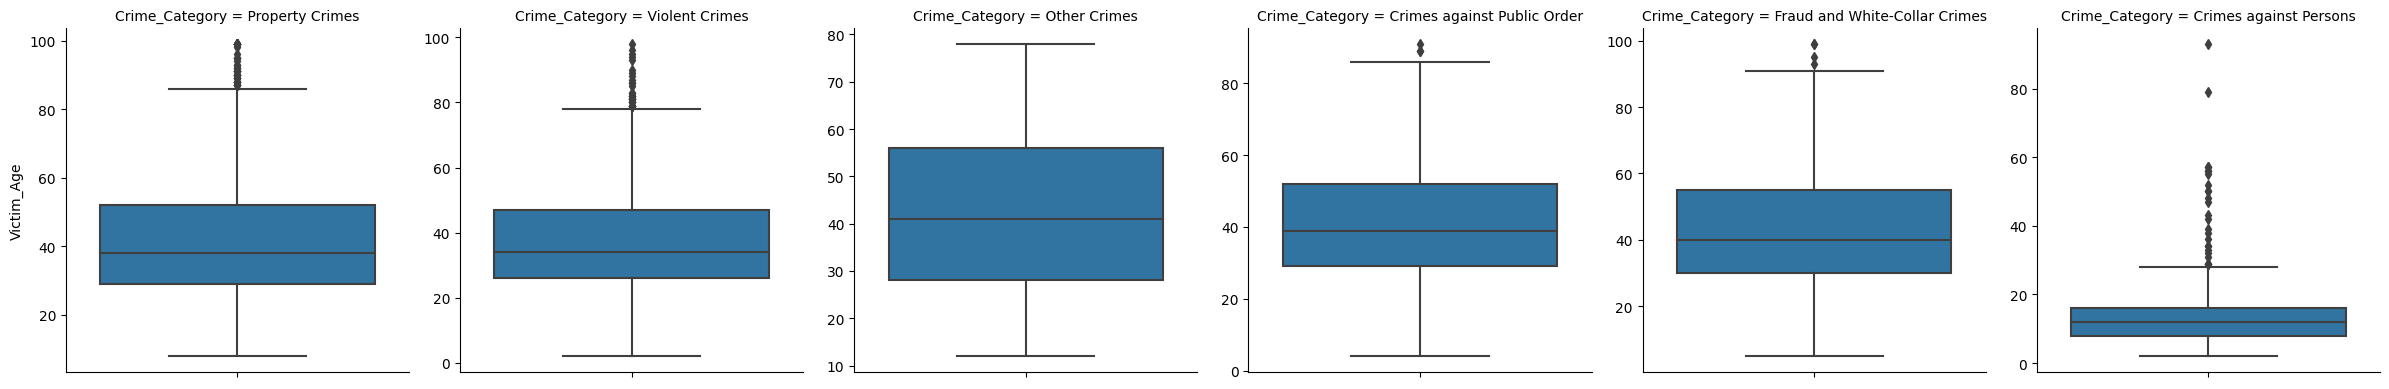

In [56]:
g = sns.FacetGrid(train,col = 'Crime_Category', col_wrap = 6, height=4, sharey=False, sharex = True)
g.map_dataframe(sns.boxplot, y ='Victim_Age' )
g.fig.tight_layout()

Most Victims are around the age 25 to 50, except for crime against persons with young children to young adults as victims. For almost all the crimes, there are some extreme cases of crime on older population. 

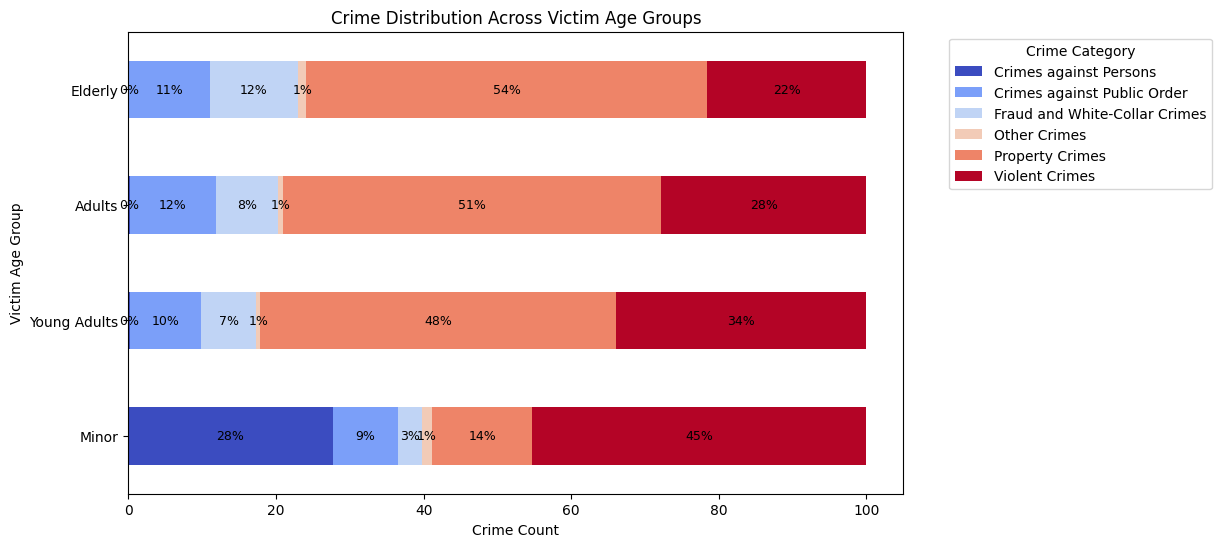

In [57]:
train_c = train.copy()
age_bins = [0, 18, 35, 60, 100]
age_labels = ['Minor', 'Young Adults', 'Adults', 'Elderly']
train_c['Age_Group'] = pd.cut(train_c['Victim_Age'], bins=age_bins, labels=age_labels)


crimevsage = pd.crosstab(index =train_c['Age_Group'],columns= train_c['Crime_Category'], normalize='index')*100
ax = crimevsage.plot(kind='barh', stacked=True, figsize=(10, 6), colormap='coolwarm')

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.text(x+width/2,
            y+height/2,
            '{:.0f}%'.format(width),
            horizontalalignment='center',
            verticalalignment='center',
            color='black',
            fontsize=9)

plt.title('Crime Distribution Across Victim Age Groups')
plt.ylabel('Victim Age Group')
plt.xlabel('Crime Count')
plt.legend(title='Crime Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

Crime against persons are all crimes on minors. And proportion of violent crimes on minors is very large compared to other age groups. Property crimes are in higher proportion for elderly, same goes with fraud and white collar crimes. Crime Against Public Order is high amongst adults.

In [58]:
# Checking the average age of the victim
average_victim_age = train.groupby('Crime_Category')['Victim_Age'].mean().reset_index()
average_victim_age.columns = ['Crime Category', 'Average Victim Age']
print(average_victim_age)

                  Crime Category  Average Victim Age
0         Crimes against Persons           15.232558
1    Crimes against Public Order           40.786475
2  Fraud and White-Collar Crimes           42.991903
3                   Other Crimes           41.788991
4                Property Crimes           41.322532
5                 Violent Crimes           37.102586


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


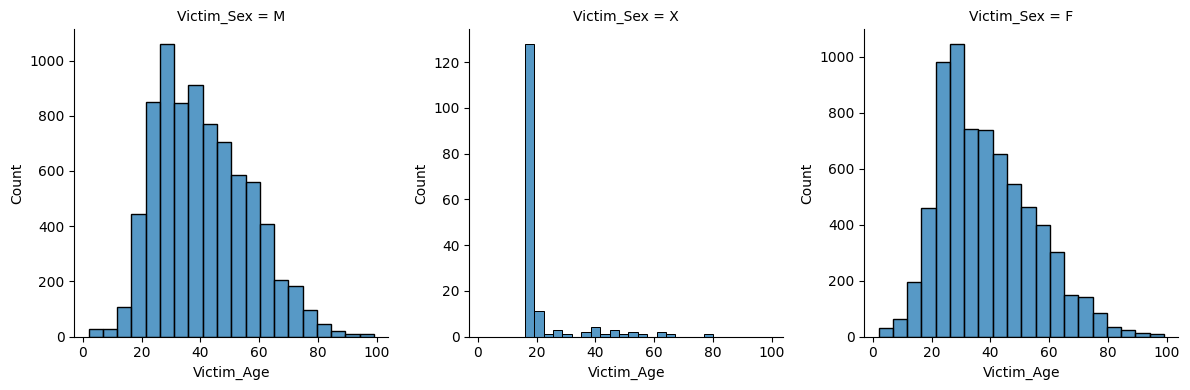

In [59]:
g = sns.FacetGrid(train,col = 'Victim_Sex', col_wrap = 3, height=4, sharey=False, sharex = True)
g.map_dataframe(sns.histplot, x ='Victim_Age', bins = 20 )
g.fig.tight_layout()

We can deduct that females in the age bracket 25-30 are more frequent victims of crime compared to males in the same age bracket. 

## Victim Descent

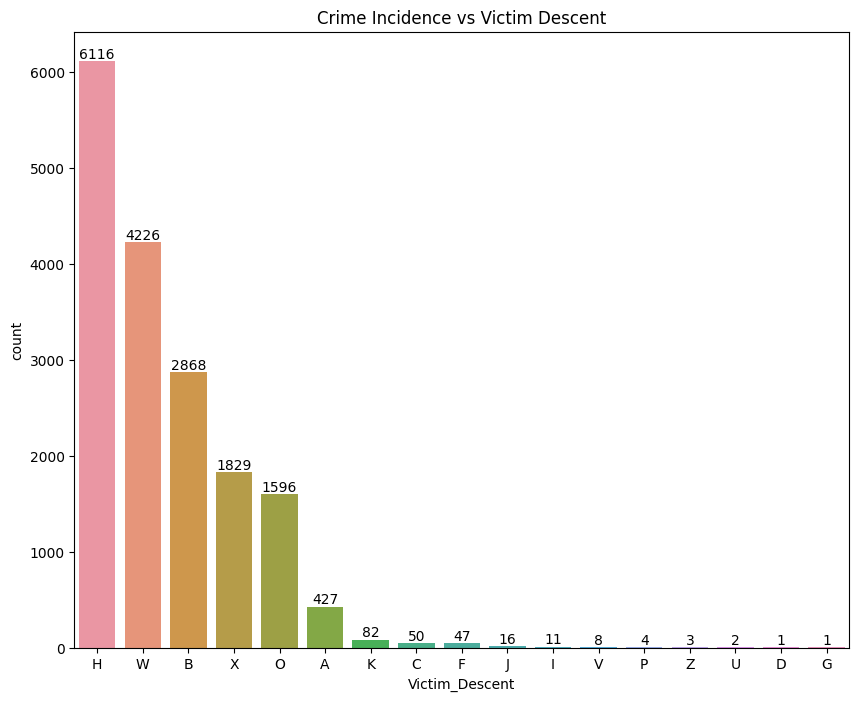

In [60]:
plt.figure(figsize = (10,8))
ax = sns.countplot(x = train['Victim_Descent'], order= train['Victim_Descent'].value_counts().index)
ax.bar_label(ax.containers[0], fontsize=10)
plt.title('Crime Incidence vs Victim Descent')
plt.show()

Victims of Descent H are highly prone to Crime incidence. 

<Figure size 1000x800 with 0 Axes>

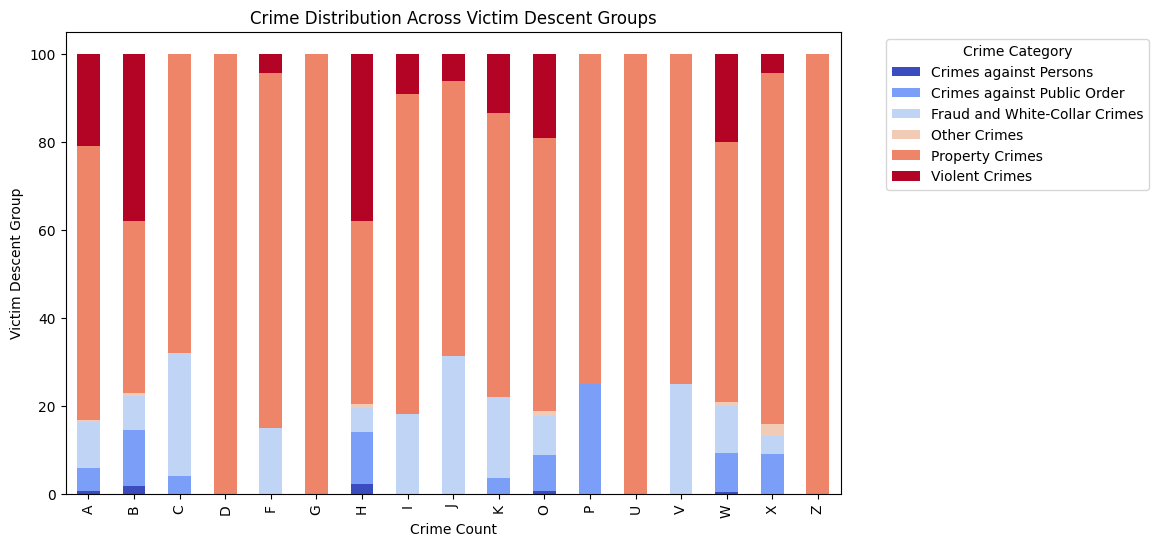

In [61]:
plt.figure(figsize= (10,8))
crimevsdescent = pd.crosstab(train['Victim_Descent'], train['Crime_Category'], normalize = 'index')*100
ax = crimevsdescent.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='coolwarm')

plt.title('Crime Distribution Across Victim Descent Groups')
plt.ylabel('Victim Descent Group')
plt.xlabel('Crime Count')
plt.legend(title='Crime Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

We observe that individuals from lineages D, U, and Z are exclusively victims of property crimes. Not every descent is represented among the victims of all crime categories.

<Figure size 1000x800 with 0 Axes>

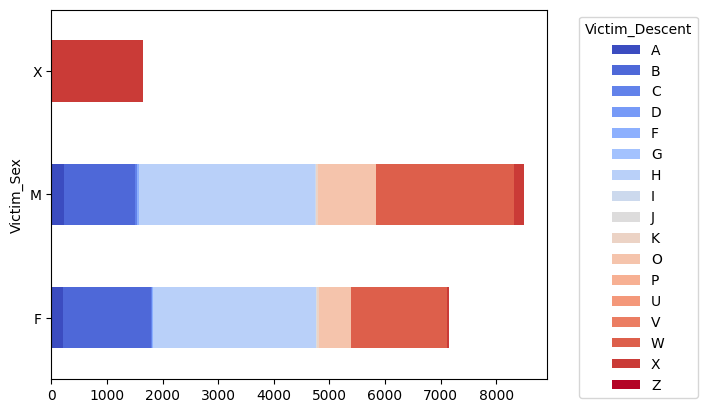

In [62]:
plt.figure(figsize=(10,8))
sexvsdescent= pd.crosstab(train['Victim_Sex'], train['Victim_Descent'])

ax = sexvsdescent.plot(kind = 'barh',stacked=True, colormap = 'coolwarm')
plt.legend(title='Victim_Descent', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

X is Unknown for Victim Descent as well. 

Since, there are few occurrences of certain victim descent, I will bin them into category 'Other'

In [63]:
Top_Victim_Descent = train['Victim_Descent'].value_counts(dropna=True)
Top_Victim_Descent = Top_Victim_Descent[Top_Victim_Descent > 100].index
train['Victim_Descent'] = train['Victim_Descent'].apply(
    lambda x: x if x in Top_Victim_Descent else ('Others' if not pd.isna(x) else np.nan)
)
train['Victim_Descent'].value_counts()

Victim_Descent
H         6116
W         4226
B         2868
X         1829
O         1596
A          427
Others     225
Name: count, dtype: int64

# When the crime happened?

We have three features reporting: Date_Occurred, Time_Occurred and Date_Reported. I will convert them into date_time features and extract useful information for further analysis

In [64]:
dt_df = pd.DataFrame()
dt_df = train[['Date_Occurred', 'Time_Occurred', 'Date_Reported']].copy()
dt_df['Date_Occurred'] = pd.to_datetime(dt_df['Date_Occurred'], format='%m/%d/%Y %I:%M:%S %p')
dt_df['Date_Reported'] = pd.to_datetime(dt_df['Date_Reported'], format='%m/%d/%Y %I:%M:%S %p')

In [65]:
dt_df['Month_Occurred'] = dt_df['Date_Occurred'].dt.month
dt_df['Year_Occurred'] = dt_df['Date_Occurred'].dt.year
dt_df['Dayofweek_O'] = dt_df['Date_Occurred'].dt.weekday
dt_df['DayofweekOname']= dt_df['Date_Occurred'].dt.day_name()
dt_df['Delayed_Reporting']= (dt_df['Date_Reported']- dt_df['Date_Occurred']).dt.days
dt_df['Time_Occurred'] = dt_df['Time_Occurred'].astype(int).astype(str).str.zfill(4)
dt_df['Hour_Occurred'] = dt_df['Time_Occurred'].str[:2].astype(int)
dt_df.head()

,Date_Occurred,Time_Occurred,Date_Reported,Month_Occurred,Year_Occurred,Dayofweek_O,DayofweekOname,Delayed_Reporting,Hour_Occurred
0,2020-03-06,1800,2020-03-09,3,2020,4,Friday,3,18
1,2020-02-27,1345,2020-02-27,2,2020,3,Thursday,0,13
2,2020-08-21,0605,2020-08-21,8,2020,4,Friday,0,6
3,2020-11-06,1800,2020-11-08,11,2020,4,Friday,2,18
4,2020-02-25,1130,2020-02-25,2,2020,1,Tuesday,0,11


In [66]:
#Creating a new feature from hour occurred
def categorize_time(hour):
    if 0 <= hour < 7:
        return 'Early Morning'
    elif 7 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 16:
        return 'Noon'
    elif 16<= hour < 19:
        return 'Evening'
    elif 19 <= hour < 24:
        return 'Night'
    else:
        return 'Unknown'  

# Create new feature
dt_df['Time_of_Day'] = dt_df['Hour_Occurred'].apply(categorize_time)

In [67]:
dt_df['Delayed_Reporting_Binned'] = pd.cut(dt_df['Delayed_Reporting'],
                                                        bins=[-np.inf, 1, 30, 183, np.inf],
                                                        labels=['Immediate', 'Withinamonth', 'Within6months', 'Morethan6months'])

In [68]:
dt_df = dt_df.drop(['Date_Occurred', 'Time_Occurred', 'Date_Reported', 'Year_Occurred', 'Delayed_Reporting'], axis = 1)
train = pd.concat([train, dt_df], axis =1)

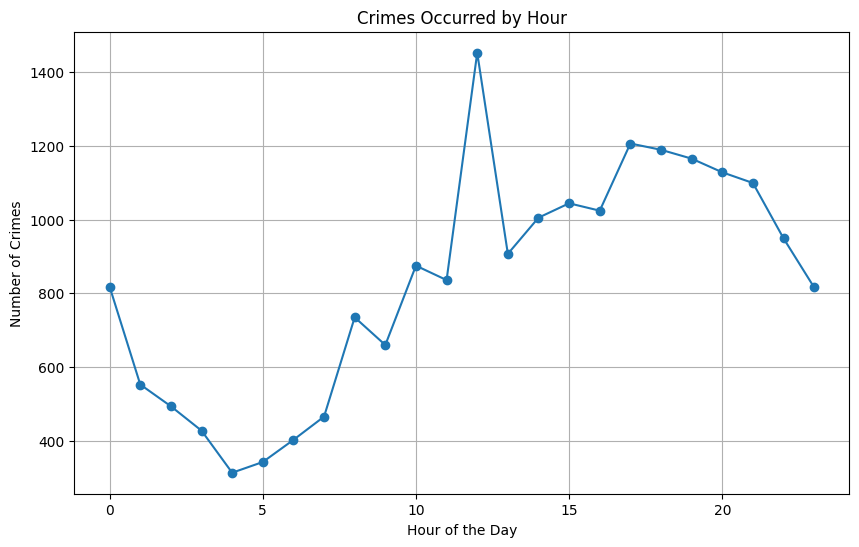

In [69]:
#Crime over a day
hourly_crime = train.groupby('Hour_Occurred').size()
plt.figure(figsize=(10, 6))
hourly_crime.plot(kind='line', marker='o')
plt.title('Crimes Occurred by Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Crimes')
plt.grid(True)
plt.show()

There is a significant spike of crimes at 12 PM. From Midnight 12AM, there is a fall in crime incidence and post early hours of the day the crime incidence increases. There is significant downtrend post 8PM at night.

Which Crimes are higher at noon?

<Figure size 2000x2000 with 0 Axes>

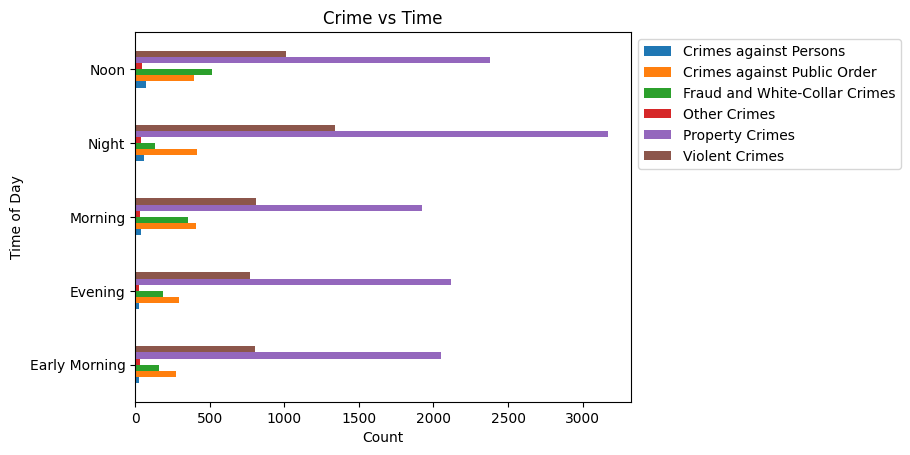

In [70]:
crimevstime = pd.crosstab(train['Time_of_Day'], train['Crime_Category'])

plt.figure(figsize = (20,20))
ax = crimevstime.plot(kind = 'barh')

plt.xlabel("Count")
plt.ylabel('Time of Day')
plt.title('Crime vs Time')
plt.legend(bbox_to_anchor = (1,1), loc ='upper left')
plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

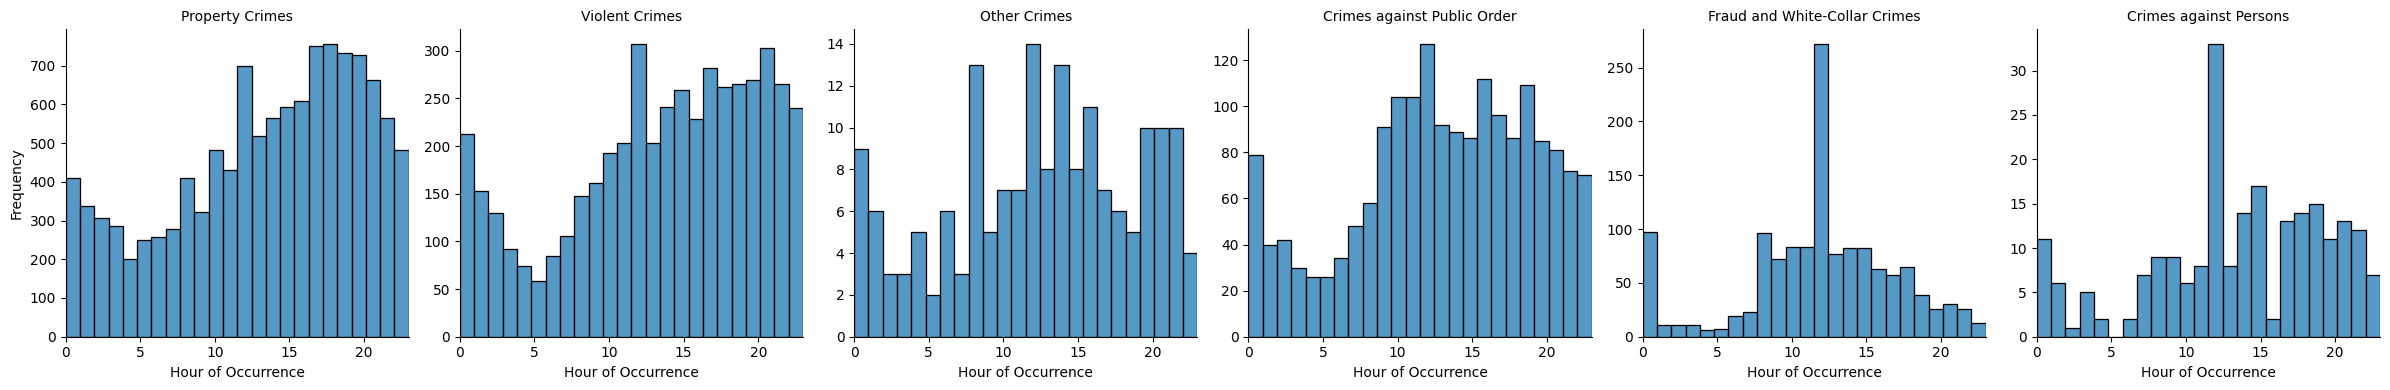

In [71]:
g = sns.FacetGrid(train, col="Crime_Category", col_wrap=6, height=4, sharex=False, sharey=False)

g.map(sns.histplot, 'Hour_Occurred', bins=24, kde=False)

g.set_axis_labels("Hour of Occurrence", "Frequency")
g.set_titles(col_template="{col_name}")
g.set(xlim=(0, 23))
g.fig.tight_layout()

plt.show()

Almost all crimes, has a significant peak at around 12 PM. Property Crimes and Violent Crimes occur mainly post 12 PM. While Other crimes are spread across the time with few peaks, more of multimodal. Crime against Public Order falls post 12 PM. Fraud and white collar crimes and Crime against persons can be seen as unimodal, with a high peak at 12 PM. It is not very clear how they note time occurred for crimes such as fraud and white collar crimes, Property Crimes because by meaning these crimes might happen over a period of time, days or months. Hourly categorisation of such crimes might not be correct.

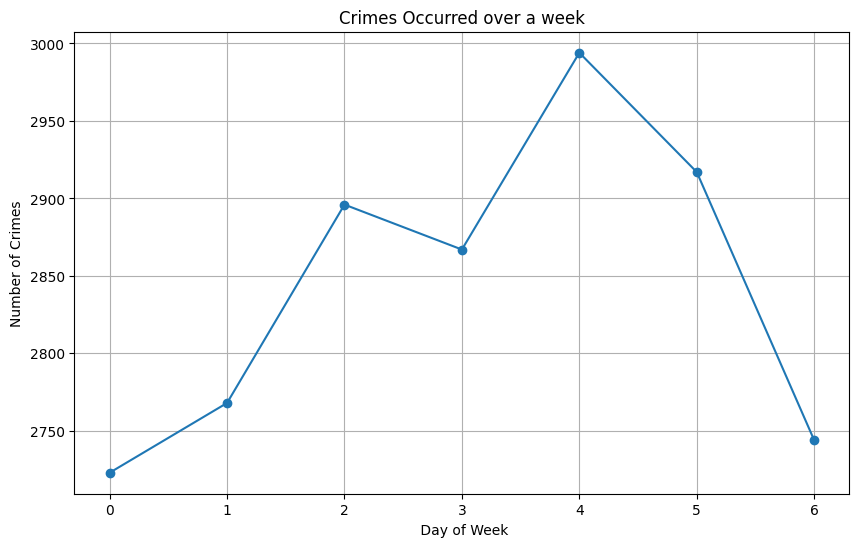

In [72]:
#Crime over a week
weekly_crime = train.groupby('Dayofweek_O').size()
plt.figure(figsize=(10, 6))
weekly_crime.plot(kind='line', marker='o')
plt.title('Crimes Occurred over a week')
plt.xlabel(' Day of Week')
plt.ylabel('Number of Crimes')
plt.grid(True)
plt.show()

The Week Day varies from 0 to 6, where 0 corresponds to Monday and 6 to Sunday. Crime Incidence are higher on a Friday and starts falling over the weekend and is very low on Monday.

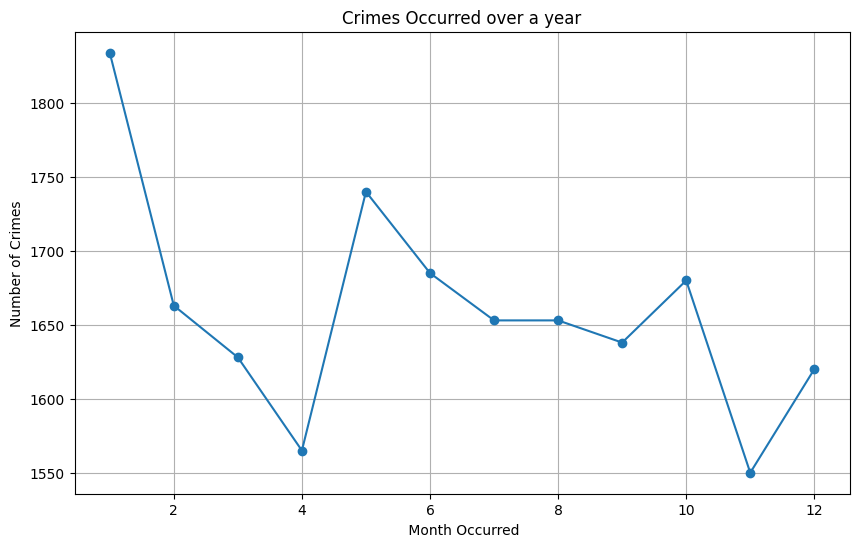

In [73]:
#Crime over a year
yearly_crime = train.groupby('Month_Occurred').size()
plt.figure(figsize=(10, 6))
yearly_crime.plot(kind='line', marker='o')
plt.title('Crimes Occurred over a year')
plt.xlabel(' Month Occurred')
plt.ylabel('Number of Crimes')
plt.grid(True)
plt.show()

Somehow January has the highest crime occurrence, falls till April. Same dip in crimes is seen in November. Such differences can be analysed further along with data on festival days or holidays.

In [74]:
pd.crosstab(train['Delayed_Reporting_Binned'], train['Crime_Category'], normalize = 'index')

Crime_Category,Crimes against Persons,Crimes against Public Order,Fraud and White-Collar Crimes,Other Crimes,Property Crimes,Violent Crimes
Delayed_Reporting_Binned,,,,,,
Immediate,0.009088,0.106278,0.021505,0.009781,0.558515,0.294832
Withinamonth,0.012322,0.044697,0.110413,0.006765,0.742691,0.083112
Within6months,0.014194,0.041290,0.365161,0.006452,0.489032,0.083871
Morethan6months,0.055172,0.065517,0.518966,0.001724,0.218966,0.139655


Violent Crimes, Crimes Against Public Order, Other Crimes are immediately reported. Property Crimes and Other Crimes takes a week to a month to report. The delay in reporting is highest for Fraud and White Collar Crimes. This might be due to finding out the culprit, because for such crime it is very often that culprit escapes or goes abscounding. Even Crime against Persons is not reported immediately.

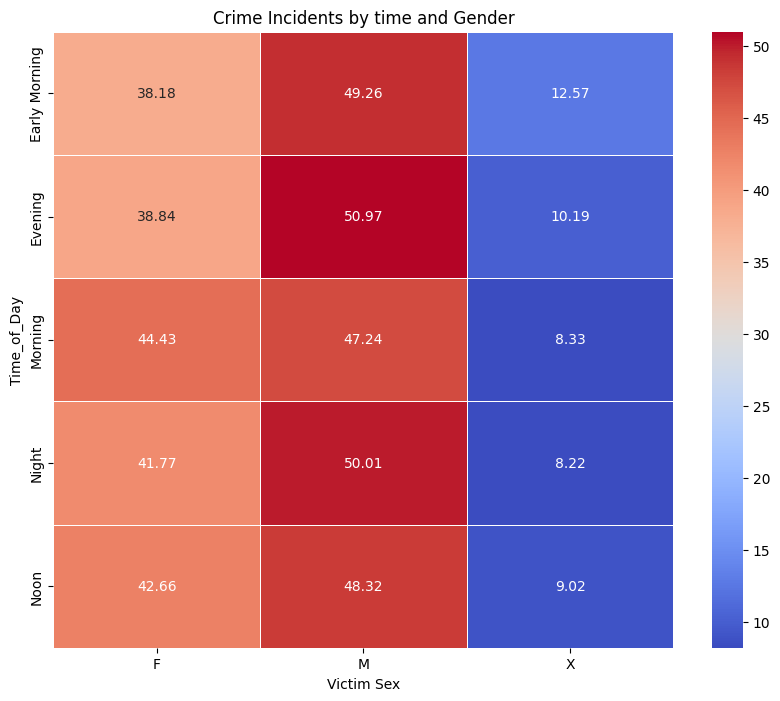

In [75]:
timevssex = pd.crosstab(train['Time_of_Day'], train['Victim_Sex'], normalize = 'index')*100
plt.figure(figsize=(10, 8))
sns.heatmap(timevssex, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Crime Incidents by time and Gender')
plt.xlabel('Victim Sex')
plt.ylabel('Time_of_Day')
plt.show()

For females, crimes occur at a higher proportion during the morning hours. In contrast, for males, a higher proportion of crimes occur during the evening and night hours. Though, overall there isn't much variation in proportion for both males and females.

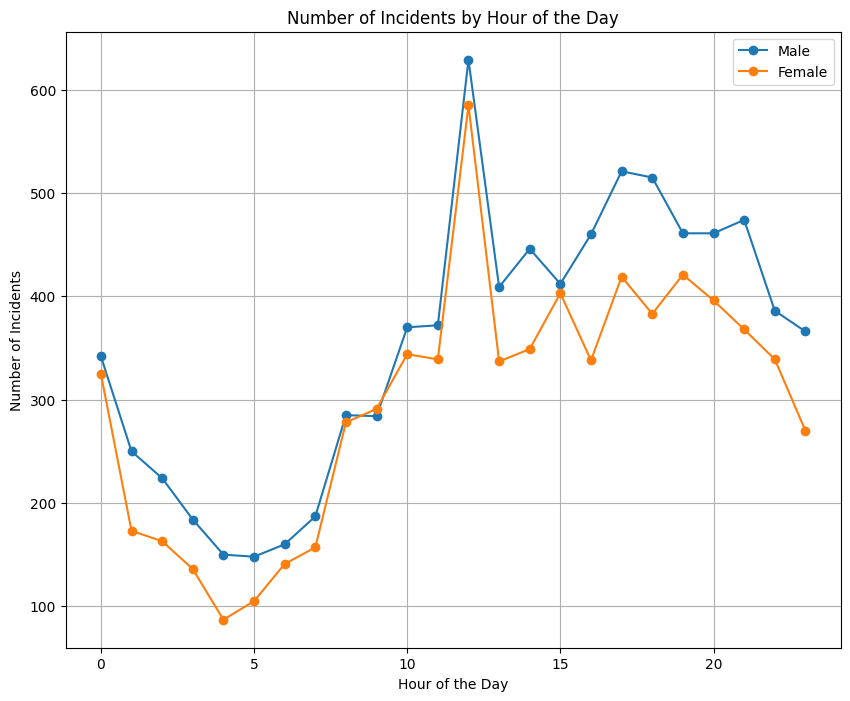

In [76]:
M_victims = train[train['Victim_Sex'] == 'M']
F_victims =train[train['Victim_Sex'] == 'F']

hourly_m = M_victims.groupby('Hour_Occurred').size()
hourly_f = F_victims.groupby('Hour_Occurred').size()


plt.figure(figsize=(10, 8))
plt.plot(hourly_m.index, hourly_m.values, label='Male', marker='o')
plt.plot(hourly_f.index, hourly_f.values, label='Female', marker='o')

plt.title('Number of Incidents by Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Incidents')
plt.legend()
plt.grid(True)

plt.show()

# Who is the culprit?


## Modus_Operandi & Part_1_2

In [77]:
#rename, to remove space
train = train.rename(columns = {'Part 1-2': 'Part_1_2'})
train['Part_1_2'].value_counts()

Part_1_2
1.0    11605
2.0     8304
Name: count, dtype: int64

There is more of Part 1 classified crimes than Part 2. From my understanding this classification is related to severity of the different crimes made by culprit. From analysing the Modus_Operandi feature along with Part 1 2, I can see clearly certain combinations of crime is classified as 1 and 2.

In [78]:
train.groupby(['Modus_Operandi', 'Part_1_2']).size().unstack(fill_value=0)

Part_1_2,1.0,2.0
Modus_Operandi,,
0100,0,71
0100 0121 0701 1822,0,1
0100 0344,0,1
0100 0344 0701 0800 1251 1822 1900,0,1
0100 0344 0701 0800 1251 1822 1914,0,1
...,...,...
2201 0344 1607,1,0
2204 0329,0,1
2204 1501 1402,1,0


Modus Operandi is an object feature with different codes for crimes convicted for each culprit and high dimensional, I will extract the MO codes in data preprocessing for model training

## Weapon Used

In [79]:
train['Weapon_Used_Code'].nunique()

57

There 57 different type of weapons used by culprits, of these strong - arm(Bodily Force) is used by almost 3967 of the attackers. Since this feature has around 63% null values, I will be dropping the feature.

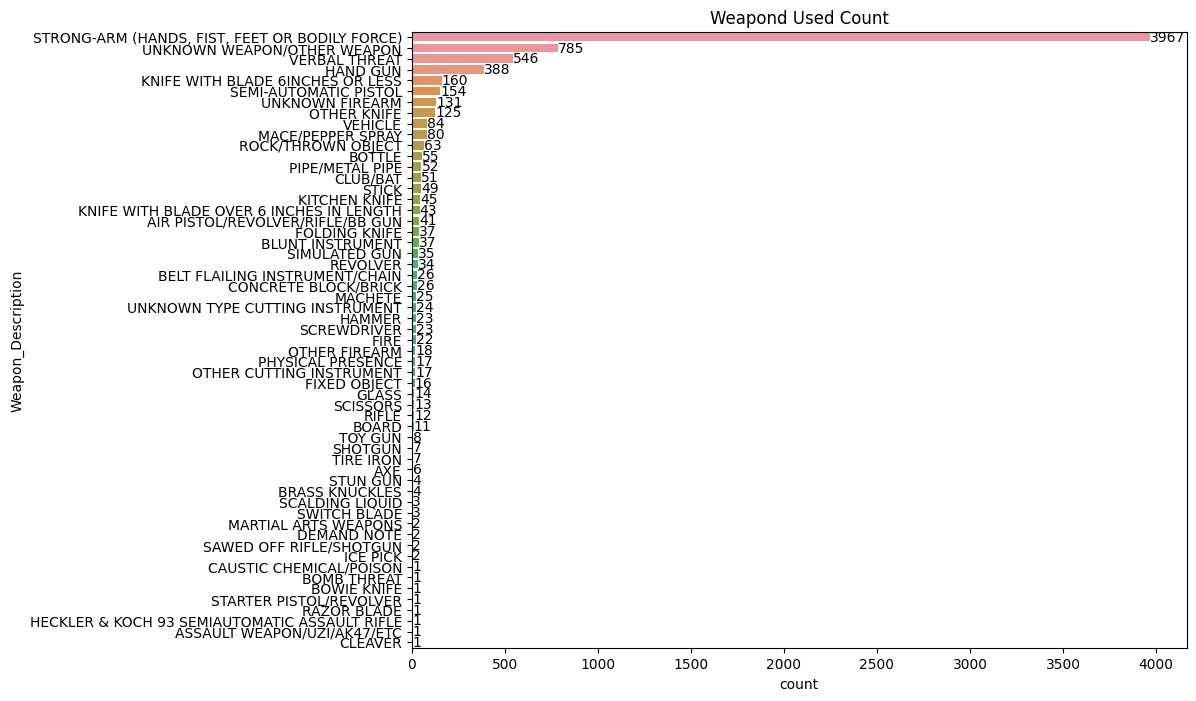

In [80]:
plt.figure(figsize = (10,8))
ax = sns.countplot(y = train['Weapon_Description'], order= train['Weapon_Description'].value_counts().index)
ax.bar_label(ax.containers[0], fontsize=10)
plt.title('Weapond Used Count')
plt.show()

# Status
It was noted in descriptive statistics that almost 70% of the cases were still under investigation, which is huge proportion. We will see which crime categories are mostly under investigation and for which there has been an arrest. 

In [81]:
pd.crosstab(train['Crime_Category'], train['Status'], normalize ='index')

Status,AA,AO,IC,JA,JO
Crime_Category,,,,,
Crimes against Persons,0.306667,0.355556,0.328889,0.004444,0.004444
Crimes against Public Order,0.180190,0.260213,0.554561,0.003358,0.001679
Fraud and White-Collar Crimes,0.028127,0.027387,0.943745,0.000000,0.000740
Other Crimes,0.188571,0.160000,0.645714,0.005714,0.000000
Property Crimes,0.064741,0.047287,0.884275,0.003009,0.000688
Violent Crimes,0.176160,0.302954,0.508861,0.005696,0.006329


Categories like Fraud and White-Collar Crimes, Property Crimes, and Crimes against Public Order have high percentages of ongoing investigations, which may indicate complexities or legal hurdles in these cases. Across all categories, juvenile involvement is minimal, suggesting that most crimes involve adults.Crimes against persons have a relatively higher proportion of adult arrests compared to other categories

I also wanted to see if certain clusters had higher crime incidence because there is less legal enforcement. This just an abstract hypothesis. I use status feature to answer this. This might be a biased analysis, but found it interesting. 

In [82]:
clustervsstatus = pd.crosstab(train['cluster_label'], train['Status'], normalize = 'index')*100
clustervsstatus

Status,AA,AO,IC,JA,JO
cluster_label,,,,,
0,8.766739,12.145749,78.604796,0.358144,0.124572
1,12.583320,14.696797,71.972037,0.308893,0.438953
2,16.411379,14.442013,68.599562,0.547046,0.000000


Cluster 2 has lesser crime incidence, and it is noticeable from here that the proportion of arrest, both juvenile and adult arrests are higher in cluster 2. This cannot establish that these regions has better legal or police enforcement, we need other factors such population, crime rates etc. to further analyse. Maybe for the future.

# Data Preprocessing


In [83]:
#Checking the columns in train before preprocessing
train.columns

Index(['Location', 'Latitude', 'Longitude', 'Date_Reported', 'Date_Occurred',
       'Time_Occurred', 'Area_ID', 'Area_Name', 'Reporting_District_no',
       'Part_1_2', 'Modus_Operandi', 'Victim_Age', 'Victim_Sex',
       'Victim_Descent', 'Premise_Code', 'Premise_Description',
       'Weapon_Used_Code', 'Weapon_Description', 'Status',
       'Status_Description', 'Crime_Category', 'cluster_label',
       'Street_Type_bin', 'Month_Occurred', 'Dayofweek_O', 'DayofweekOname',
       'Hour_Occurred', 'Time_of_Day', 'Delayed_Reporting_Binned'],
      dtype='object')

In [84]:
#Removing redudnant and irrelevant features.
train=train.drop(['Location','Latitude', 'Longitude','Date_Reported',
       'Date_Occurred', 'Time_Occurred', 'Area_ID', 'Area_Name','Premise_Description',
       'Weapon_Used_Code', 'Weapon_Description','Status_Description',
        'DayofweekOname','Hour_Occurred'
                 ], axis =1)

In [85]:
#Appropriate conversions for preprocessing
train['Reporting_District_no'] = train['Reporting_District_no'].astype(int)
train['Part_1_2'] = train['Part_1_2'].astype(int)
train['Premise_Code']= train['Premise_Code'].astype(str)

In [86]:
train.columns

Index(['Reporting_District_no', 'Part_1_2', 'Modus_Operandi', 'Victim_Age',
       'Victim_Sex', 'Victim_Descent', 'Premise_Code', 'Status',
       'Crime_Category', 'cluster_label', 'Street_Type_bin', 'Month_Occurred',
       'Dayofweek_O', 'Time_of_Day', 'Delayed_Reporting_Binned'],
      dtype='object')

In [87]:
X, y = train.drop(['Crime_Category'],axis =1), train['Crime_Category'].copy()
le = LabelEncoder()
y=le.fit_transform(y)
print(le.classes_)

['Crimes against Persons' 'Crimes against Public Order'
 'Fraud and White-Collar Crimes' 'Other Crimes' 'Property Crimes'
 'Violent Crimes']


In [88]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.3, 
                                                  random_state=0, 
                                                  stratify=y)#used stratification of y to handle imbalance
print(f'X_train shape : {X_train.shape}, X_test shape : {X_val.shape}, y_train.shape: {y_train.shape},y_test shape : {y_val.shape}')

X_train shape : (13936, 14), X_test shape : (5973, 14), y_train.shape: (13936,),y_test shape : (5973,)


In [89]:
#Function to split Modus Operandi feature during preprocessing
def to_string_and_split(text_array):
    return [str(text).split() for text in text_array]

In [90]:
text_pipe1 = Pipeline([('imputer', SimpleImputer(strategy='constant', fill_value='')),
                       ('splitter', FunctionTransformer(to_string_and_split)),
                       ('tfidf', TfidfVectorizer(tokenizer=lambda x: x, lowercase=False, 
                                                 preprocessor=lambda x: x))])#Modus_Operandi
num_std_with_imp = Pipeline([('impute', SimpleImputer(strategy="median"))])#Victim_Age
ohe_with_imp = Pipeline([("impute",SimpleImputer(strategy= 'constant', fill_value='Missing')),
                         ("ohe", OneHotEncoder(handle_unknown= 'ignore'))])#Victim_Sex #Victim_Descent #Street Type
ord_cat_pipe = Pipeline([('ord', OrdinalEncoder())])#Time of Day, Month Occurred Day, Day of week, Delayed reporting binned
ohe_pipe = Pipeline([("ohe", OneHotEncoder(handle_unknown = 'ignore'))])#status, part 1 2, Reporting District no, Premise Code

trf1 = ColumnTransformer([
    ("num_std", num_std_with_imp, ['Victim_Age']),
    ("ohe_impute", ohe_with_imp,['Victim_Sex', 'Victim_Descent', 'Street_Type_bin']),
    ('ohe', ohe_pipe, ['Premise_Code','Reporting_District_no','Status', 'Part_1_2']),
    ('ord',ord_cat_pipe,['Time_of_Day','Month_Occurred','Dayofweek_O','Delayed_Reporting_Binned'])])
trf2 = ColumnTransformer([('text_pipe',text_pipe1,['Modus_Operandi'])])

union = FeatureUnion([('transformer1',trf1),('transformer2',trf2)])

In [91]:
X_train_transformed = union.fit_transform(X_train)
X_val_transformed = union.transform(X_val)
X_train_transformed.shape

/opt/conda/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:528: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


(13936, 2229)

# Model Training

## Baseline Model: Random Forest Classifier

I chose to build my baseline using Random Forest Classifer, since it is suited to handle high dimesional features and imbalance well.

In [92]:
rfc = RandomForestClassifier(random_state = 42, class_weight = 'balanced')
rfc.fit(X_train_transformed, y_train)
y_pred_rfc = rfc.predict(X_val_transformed)
print(accuracy_score(y_val, y_pred_rfc))
print(classification_report(y_val, y_pred_rfc))

0.9022266867570735
              precision    recall  f1-score   support

           0       0.80      0.54      0.65        68
           1       0.82      0.52      0.64       536
           2       0.87      0.89      0.88       405
           3       1.00      0.02      0.04        53
           4       0.94      0.98      0.96      3489
           5       0.84      0.90      0.87      1422

    accuracy                           0.90      5973
   macro avg       0.88      0.64      0.67      5973
weighted avg       0.90      0.90      0.89      5973



For the majority classes (like Class 4 and Class 5), the model performs exceptionally well, with high precision, recall, and F1-scores. But,the model struggles with classes that have fewer instances (Class 0 and Class 3), as indicated by their low recall and F1-scores. It is necessary to improve recall of minority classes to address the imbalance

## Feature Selection methods

I employed SelectkBest feature selection method using two score_func and chose the best performing feature selection method based on baseline model.

In [93]:
#svd
#svd = TruncatedSVD(n_components = 1000)
#X_train_reduced = svd.fit_transform(X_train_transformed)
#X_test_reduced = svd.transform(X_val_transformed)

#X_train_svd = pd.DataFrame(X_train_reduced)
#X_val_svd = pd.DataFrame(X_test_reduced)

In [94]:
#SelectKbest
#warnings.filterwarnings("ignore")
#selector = SelectKBest(score_func = mutual_info_classif, k=1000)

#X_train_mi = selector.fit_transform(X_train_transformed, y_train)
#X_test_mi = selector.transform(X_val_transformed)

#X_train_mif = pd.DataFrame(X_train_mi.toarray())
#X_val_mif = pd.DataFrame(X_test_mi.toarray())

In [95]:
#selector = SelectKBest(score_func = chi2, k=1000)

#X_train_chi2 = selector.fit_transform(X_train_transformed, y_train)
#X_test_chi2 = selector.transform(X_val_transformed)

#X_train_chif = pd.DataFrame(X_train_chi2.toarray())
#X_val_chif = pd.DataFrame(X_test_chi2.toarray())

In [96]:
#rfc.fit(X_train_svd, y_train)
#y_pred_rfc_svd = rfc.predict(X_val_svd)
#print(accuracy_score(y_val, y_pred_rfc_svd))
#print(classification_report(y_val, y_pred_rfc_svd))

0.8662313745186674

              precision    recall  f1-score   support

           0       0.50      0.01      0.03        68
           1       0.85      0.42      0.56       536
           2       0.92      0.77      0.84       405
           3       0.00      0.00      0.00        53
           4       0.89      0.99      0.94      3489
           5       0.80      0.83      0.81      1422

    accuracy                           0.87      5973
   macro avg       0.66      0.50      0.53      5973

weighted avg       0.85      0.87      0.85      5973

In [97]:
#rfc.fit(X_train_chif, y_train)
#y_pred_chif = rfc.predict(X_val_chif)
#print(accuracy_score(y_val, y_pred_chif))
#print(classification_report(y_val, y_pred_chif))

In [98]:
#rfc.fit(X_train_mif, y_train)
#y_pred_mif = rfc.predict(X_val_mif)
#print(accuracy_score(y_val, y_pred_mif))
#print(classification_report(y_val, y_pred_mif))

Both mutual info and chi2 accuracy is similar. However, Chi2 has a higher f1 score for both minority classes and macro f1 comparatively. Hence, I chose to you Select K best with score = chi2

In [99]:
warnings.filterwarnings("ignore")
rfc_pipeline = Pipeline([('preprocessing',union),
                         ('feature_selection',SelectKBest(score_func = chi2, k=1000)),
                         ('rfc',RandomForestClassifier(random_state = 42, class_weight = 'balanced'))])
rfc_pipeline.fit(X_train,y_train)
y_pred_rfc = rfc_pipeline.predict(X_val)
print(accuracy_score(y_val, y_pred_rfc))
print(classification_report(y_val, y_pred_rfc))

0.9052402477816842
              precision    recall  f1-score   support

           0       0.71      0.54      0.62        68
           1       0.81      0.55      0.66       536
           2       0.88      0.91      0.89       405
           3       1.00      0.06      0.11        53
           4       0.95      0.98      0.97      3489
           5       0.83      0.90      0.87      1422

    accuracy                           0.91      5973
   macro avg       0.86      0.66      0.68      5973
weighted avg       0.90      0.91      0.90      5973



<Figure size 1500x1200 with 0 Axes>

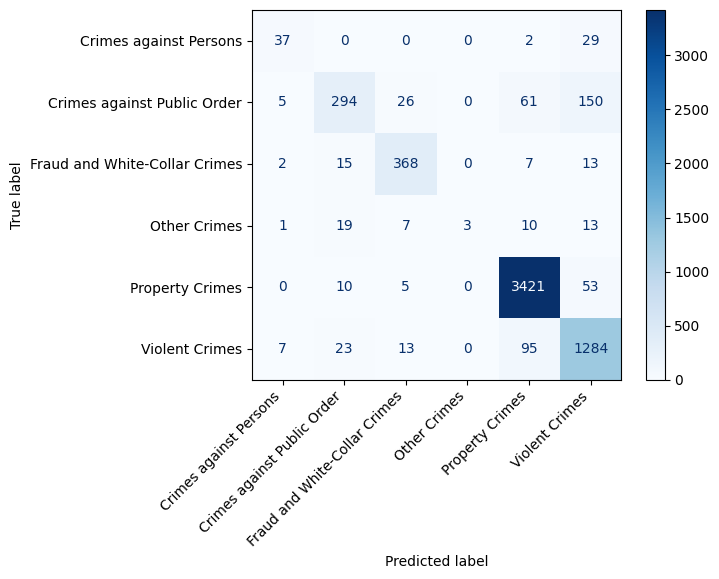

In [100]:
cm = confusion_matrix(y_val,y_pred_rfc)
plt.figure(figsize = (15,12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Crimes against Persons', 'Crimes against Public Order',
 'Fraud and White-Collar Crimes', 'Other Crimes' ,'Property Crimes',
 'Violent Crimes']) 
disp.plot(cmap=plt.cm.Blues) 
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.show()

The model works well with majority classes 4 & 5, however there is still high level misclassification. Especially with crime against public order is highly misclassified with violent crimes. The model is not doing well with minority class Other Crimes, as only 7 is correctly identified. 

In [101]:
from sklearn.ensemble import AdaBoostClassifier
adb_pipeline = Pipeline([('preprocessing',union),
                         ('feature_selection',SelectKBest(score_func = chi2, k=1000)),
                         ('xgb',AdaBoostClassifier(random_state = 42))])
adb_pipeline.fit(X_train,y_train)
y_pred_adb = adb_pipeline.predict(X_val)
print(accuracy_score(y_val, y_pred_adb))
print(classification_report(y_val, y_pred_adb))


0.7214130252804286
              precision    recall  f1-score   support

           0       0.35      0.75      0.48        68
           1       0.00      0.00      0.00       536
           2       0.06      0.00      0.00       405
           3       0.00      0.00      0.00        53
           4       0.86      0.97      0.91      3489
           5       0.47      0.62      0.54      1422

    accuracy                           0.72      5973
   macro avg       0.29      0.39      0.32      5973
weighted avg       0.62      0.72      0.66      5973



In [102]:
from imblearn.ensemble import BalancedRandomForestClassifier
ee_pipeline = Pipeline([('preprocessing',union),
                         ('feature_selection',SelectKBest(score_func = chi2, k=1000)),
                         ('xgb',BalancedRandomForestClassifier(random_state = 42))])
ee_pipeline.fit(X_train,y_train)
y_pred_ee = ee_pipeline.predict(X_val)
print(accuracy_score(y_val, y_pred_ee))
print(classification_report(y_val, y_pred_ee))

0.7885484681064792
              precision    recall  f1-score   support

           0       0.32      0.82      0.46        68
           1       0.58      0.50      0.53       536
           2       0.63      0.91      0.74       405
           3       0.07      0.60      0.12        53
           4       0.95      0.87      0.91      3489
           5       0.89      0.66      0.76      1422

    accuracy                           0.79      5973
   macro avg       0.57      0.73      0.59      5973
weighted avg       0.86      0.79      0.82      5973



<Figure size 1500x1200 with 0 Axes>

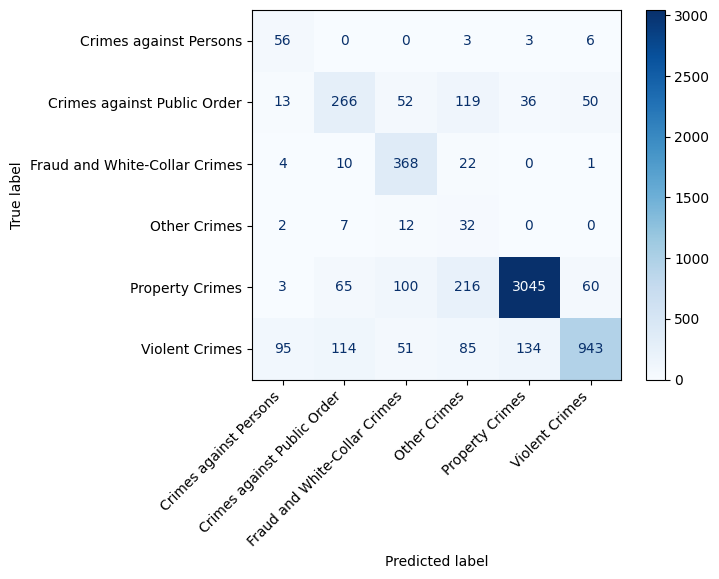

In [103]:
cm = confusion_matrix(y_val,y_pred_ee)
plt.figure(figsize = (15,12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Crimes against Persons', 'Crimes against Public Order',
 'Fraud and White-Collar Crimes', 'Other Crimes' ,'Property Crimes',
 'Violent Crimes']) 
disp.plot(cmap=plt.cm.Blues) 
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.show()

## Gradient Boosting Classifier

In [104]:
from sklearn.ensemble import GradientBoostingClassifier
gbc_pipeline = Pipeline([('preprocessing',union),
                         ('feature_selection',SelectKBest(score_func = chi2, k=1000)),
                         ('xgb', GradientBoostingClassifier(random_state = 42))])
gbc_pipeline.fit(X_train,y_train)
y_pred_gbc = gbc_pipeline.predict(X_val)
print(accuracy_score(y_val, y_pred_gbc))
print(classification_report(y_val, y_pred_gbc))

0.9188012723924326
              precision    recall  f1-score   support

           0       0.70      0.59      0.64        68
           1       0.87      0.69      0.77       536
           2       0.91      0.88      0.90       405
           3       0.36      0.08      0.12        53
           4       0.96      0.99      0.97      3489
           5       0.85      0.89      0.87      1422

    accuracy                           0.92      5973
   macro avg       0.78      0.69      0.71      5973
weighted avg       0.91      0.92      0.91      5973



<Figure size 1500x1200 with 0 Axes>

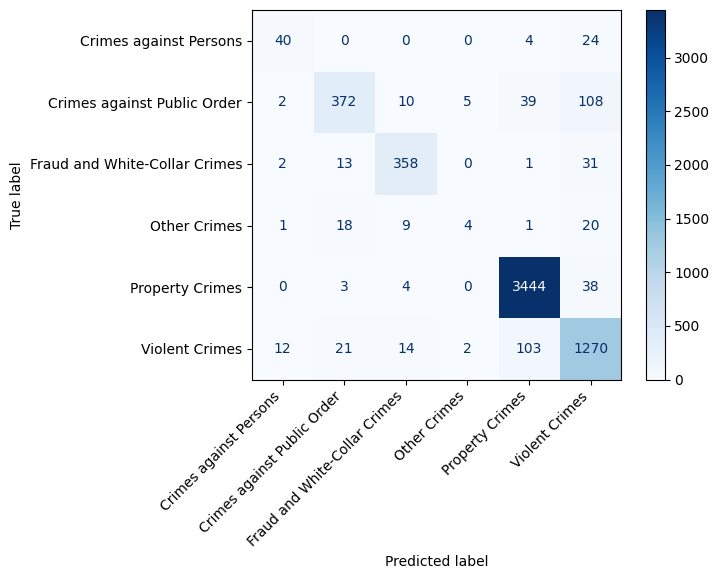

In [105]:
cm = confusion_matrix(y_val,y_pred_gbc)
plt.figure(figsize = (15,12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Crimes against Persons', 'Crimes against Public Order',
 'Fraud and White-Collar Crimes', 'Other Crimes' ,'Property Crimes',
 'Violent Crimes']) 
disp.plot(cmap=plt.cm.Blues) 
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.show()

## XGB Classifier

In [106]:
xgb_pipeline = Pipeline([('preprocessing',union),
                         ('feature_selection',SelectKBest(score_func = chi2, k=1000)),
                         ('xgb',XGBClassifier(random_state = 42, objective='mulit:softmax', num_class= 6))])
xgb_pipeline.fit(X_train,y_train)
y_pred_xgb = xgb_pipeline.predict(X_val)
print(accuracy_score(y_val, y_pred_xgb))
print(classification_report(y_val, y_pred_xgb))

0.941570400133936
              precision    recall  f1-score   support

           0       0.71      0.66      0.69        68
           1       0.84      0.80      0.82       536
           2       0.91      0.92      0.92       405
           3       0.50      0.15      0.23        53
           4       0.98      0.99      0.98      3489
           5       0.90      0.93      0.92      1422

    accuracy                           0.94      5973
   macro avg       0.81      0.74      0.76      5973
weighted avg       0.94      0.94      0.94      5973



<Figure size 1500x1200 with 0 Axes>

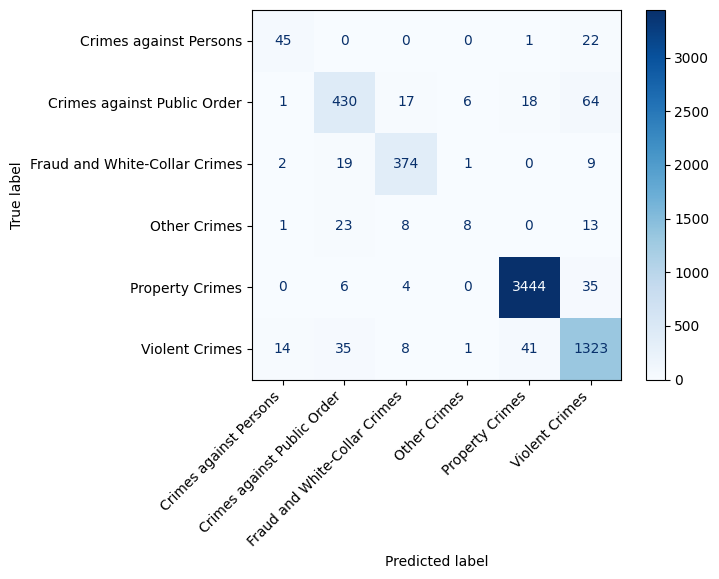

In [107]:
cm = confusion_matrix(y_val,y_pred_xgb)
plt.figure(figsize = (15,12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Crimes against Persons', 'Crimes against Public Order',
 'Fraud and White-Collar Crimes', 'Other Crimes' ,'Property Crimes',
 'Violent Crimes']) 
disp.plot(cmap=plt.cm.Blues) 
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.show()

You can see this model performing a slight better than random forest in handling minority classes and avoiding misclassifications. Missclassifications have reduced overall compared to Random Forest Classifer but it is still prevalent for classes. The model struggles to distinguish between violent crimes and other classes 

## LGBM Classifier

In [108]:
lgb_pipeline = Pipeline([('preprocessing',union),
                         ('feature_selection',SelectKBest(score_func = chi2, k=1000)),
                         ('xgb',LGBMClassifier(random_state = 42, objective = 'multiclass', num_class = 6))])
lgb_pipeline.fit(X_train,y_train)
y_pred_lgb = lgb_pipeline.predict(X_val)
print(accuracy_score(y_val, y_pred_lgb))
print(classification_report(y_val, y_pred_lgb))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.030227 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11268
[LightGBM] [Info] Number of data points in the train set: 13936, number of used features: 414
[LightGBM] [Info] Start training from score -4.485985
[LightGBM] [Info] Start training from score -2.410532
[LightGBM] [Info] Start training from score -2.689988
[LightGBM] [Info] Start training from score -4.738210
[LightGBM] [Info] Start training from score -0.537440
[LightGBM] [Info] Start training from score -1.435113
0.9383894190524025
              precision    recall  f1-score   support

           0       0.68      0.56      0.61        68
           1       0.80      0.79      0.80       536
           2       0.90      0.92      0.91       405
           3       1.00      0.13      0.23        53
           4       0.99      0.

<Figure size 1500x1200 with 0 Axes>

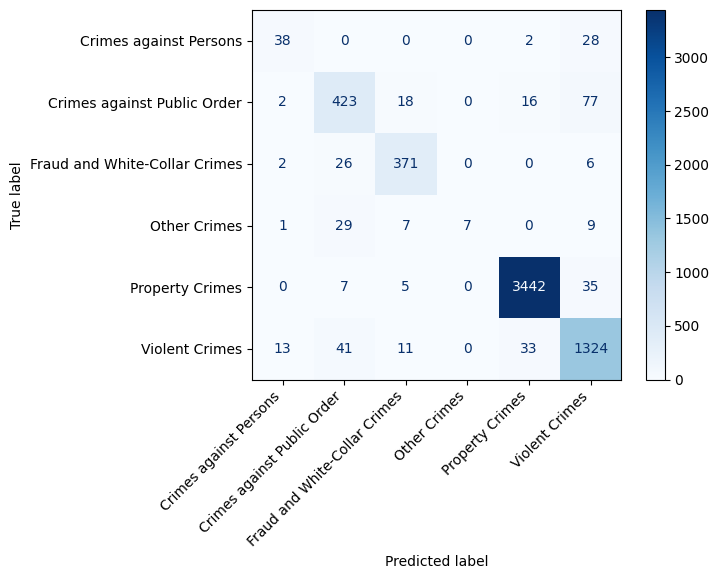

In [109]:
cm = confusion_matrix(y_val,y_pred_lgb)
plt.figure(figsize = (15,12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Crimes against Persons', 'Crimes against Public Order',
 'Fraud and White-Collar Crimes', 'Other Crimes' ,'Property Crimes',
 'Violent Crimes'])  # classes is an array of your class labels
disp.plot(cmap=plt.cm.Blues) 
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.show()

Both XGB and LGBM work almost similar, but XGB works better with minority classes. There is a balance between precision and recall in XGB model compared to LightGBM

**Overall Inference from Confusion Matrix**

Crimes Against Persons and Violent Crimes: The model consistently struggles to differentiate between these two categories. This can suggests possible overlap in features or characteristics used by the model to classify these crimes.

Crimes Against Public Order: This category is consistently misclassified, particularly into Violent Crimes and Fraud and White-Collar Crimes. 

Property Crimes: The model consistently performs well in this category across all matrices, indicating that the features used for classification are likely distinct and well-captured by the model.

Other Crimes: there is high rate of misclassification across all models. 

# XGB Classifer Hyperparameter tuning

In [110]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

In [111]:
#Handling imbalance
#from sklearn.utils import compute_class_weight
#class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)

In [112]:
#params = {
    
    #'n_estimators': [100, 200,500],
     
    # 'learning_rate': [0.05, 0.1, 0.15],
    
    #'max_depth': [3, 7,10],
    
    #'min_child_weight': [1, 10, 50],
    
    #'gamma':  [0.5, 1, 1.5],
    
    #'subsample': [ 0.5,0.75, 1],
  
  #'colsample_bylevel': [ 0.5, 0.75, 1]
   # }


#xgb = XGBClassifier(objective='multi:softmax',num_class = 6, random_state=42)


#stratified_kfold = StratifiedKFold(n_splits=3, shuffle = True, random_state=42)


#random_search= RandomizedSearchCV(xgb, params, scoring='f1_weighted', n_jobs=-1, cv=stratified_kfold, verbose=2, n_iter = 20)


#random_search.fit(X_train_skb, y_train)

In [113]:
#best_params = random_search.best_params_
#best_params

{'subsample': 0.5,
 'n_estimators': 200,
 'min_child_weight': 1,
 'max_depth': 7,
 'learning_rate': 0.15,
 'gamma': 1,
 'colsample_bylevel': 1}

In [114]:
#xgb_pipeline1 = Pipeline([('preprocessing',union),
                         #('feature_selection',SelectKBest(score_func = mutual_info_classif, k=1000)),
                        #('xgb',XGBClassifier(objective='multi:softmax',num_class=6, seed = 42, sample_weight = sample_weight, eta = 0.15, subsample = 0.5,
                  # min_child_weight = 1, max_depth = 7, gamma=1, colsample_bylevel=1))])
#xgb_pipeline1.fit(X_train,y_train)
#y_pred_xgb1 = xgb_pipeline1.predict(X_val)
#print(accuracy_score(y_val, y_pred_xgb1))
#print(classification_report(y_val, y_pred_xgb1))

In [115]:
#cm = confusion_matrix(y_val,y_pred_xgb)
#plt.figure(figsize = (15,12))
#disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Crimes against Persons', 'Crimes against Public Order',
 #'Fraud and White-Collar Crimes', 'Other Crimes' ,'Property Crimes',
 #'Violent Crimes'])  # classes is an array of your class labels
#disp.plot(cmap=plt.cm.Blues) 
#plt.xticks(rotation=45, ha='right', fontsize=10)
#plt.show()

In [116]:
#params = {'n_estimators': [100, 200,500],
     #'learning_rate': [0.05, 0.075, 0.1],
   #'max_depth': [3, 7,9],
    #'min_child_weight': [2, 10, 15],
    #'gamma':  [0.5, 1, 1.5],
#'colsample_bytree': [0.5, 0.8],
 #   'subsample': [ 0.5,0.8]
  #}

#xgb = XGBClassifier(objective='multi:softmax',num_class=6, seed = 4)
#random_search = RandomizedSearchCV(
    #estimator=xgb,
   # param_distributions=params,
    #n_iter=25,
    #scoring='f1_macro',
    #n_jobs=-1,
    #cv=3,
    #verbose=2,
    #random_state=42
#)

#random_search.fit(
 #  X_train_chif, y_train,
  #  eval_set=[(X_val_chif, y_val)],
 #eval_metric='mlogloss',
  #  early_stopping_rounds=10,
  #  verbose=True
#)

In [117]:
#random_search.best_params_

{'subsample': 0.75, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 10, 'max_delta_step': 3, 'learning_rate': 0.15, 'gamma': 0.5, 'colsample_bylevel': 0.5}

In [118]:
xgb_pipeline= Pipeline([('preprocessing',union),
                         ('feature_selection',SelectKBest(score_func = chi2, k=1000)),
                         ('xgb',XGBClassifier(objective='multi:softmax',num_class=6, seed = 42, 
                                              n_estimators=500,
                                              eta = 0.15, subsample = 1,
                                              min_child_weight = 1, max_depth = 10, 
                                              gamma=0.5,colsample_bytree=0.5,
                                              colsample_bylevel=0.5,
                                              max_delta_step = 3))])
xgb_pipeline.fit(X_train,y_train)
y_pred_xgb = xgb_pipeline.predict(X_val)
print(accuracy_score(y_val, y_pred_xgb))
print(classification_report(y_val, y_pred_xgb))

0.9429097605893186
              precision    recall  f1-score   support

           0       0.71      0.66      0.69        68
           1       0.83      0.80      0.82       536
           2       0.91      0.93      0.92       405
           3       0.55      0.21      0.30        53
           4       0.98      0.99      0.99      3489
           5       0.91      0.93      0.92      1422

    accuracy                           0.94      5973
   macro avg       0.82      0.75      0.77      5973
weighted avg       0.94      0.94      0.94      5973



<Figure size 1500x1200 with 0 Axes>

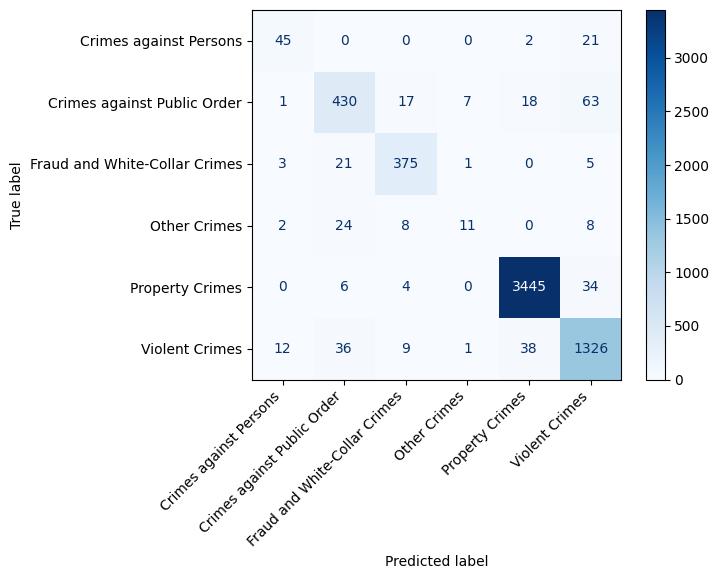

In [119]:
cm = confusion_matrix(y_val,y_pred_xgb)
plt.figure(figsize = (15,12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Crimes against Persons', 'Crimes against Public Order',
 'Fraud and White-Collar Crimes', 'Other Crimes' ,'Property Crimes',
 'Violent Crimes'])  # classes is an array of your class labels
disp.plot(cmap=plt.cm.Blues) 
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.show()

In [120]:
#params = {'n_estimators': [100, 200,500],
     #'learning_rate': [0.05, 0.075, 0.15],
   # 'max_depth': [3, 7,10],
    #'min_child_weight': [1, 10, 50],
    #'gamma':  [0.5, 1, 1.5],
    #'subsample': [ 0.5,0.75, 1],
  #'colsample_bytree': [ 0.5, 0.75, 1],
#'max_delta_step':[1,3]
 #   }

#xgb = XGBClassifier(objective='multi:softmax',num_class=6, seed = 42, sample_weight = class_weight)
#random_search = RandomizedSearchCV(
    #estimator=xgb,
    #param_distributions=params,
    #n_iter=25,
    #scoring='f1_weighted',
    #n_jobs=-1,
    #cv=3,
    #verbose=2,
    #random_state=42
#)

#random_search.fit(
  #  X_train_skb, y_train,
  #  eval_set=[(X_val_skb, y_val)],
   # eval_metric='mlogloss',
   # early_stopping_rounds=10,
    #verbose=True
#)

In [121]:
#random_search.best_params_

{'subsample': 0.75,
 'n_estimators': 500,
 'min_child_weight': 1,
 'max_depth': 10,
 'max_delta_step': 3,
 'learning_rate': 0.15,
 'gamma': 0.5,
 'colsample_bylevel': 0.5}

In [122]:
xgb_pipeline_f = Pipeline([('preprocessing',union),
                         ('feature_selection',SelectKBest(score_func = chi2, k=1000)),
                         ('xgb',XGBClassifier(objective='multi:softmax',num_class=6, seed = 42, 
                                            n_estimators=500,
                                              eta = 0.15, subsample = 0.75,
                                              min_child_weight = 1, max_depth = 10, 
                                              gamma=0.5, colsample_bytree=0.5, max_delta_step = 3))])
xgb_pipeline_f.fit(X_train,y_train)
y_pred_xgb = xgb_pipeline_f.predict(X_val)
print(accuracy_score(y_val, y_pred_xgb))
print(classification_report(y_val, y_pred_xgb))

0.944416541101624
              precision    recall  f1-score   support

           0       0.73      0.66      0.69        68
           1       0.83      0.81      0.82       536
           2       0.91      0.92      0.92       405
           3       0.50      0.17      0.25        53
           4       0.98      0.99      0.99      3489
           5       0.91      0.94      0.93      1422

    accuracy                           0.94      5973
   macro avg       0.81      0.75      0.77      5973
weighted avg       0.94      0.94      0.94      5973



<Figure size 1500x1200 with 0 Axes>

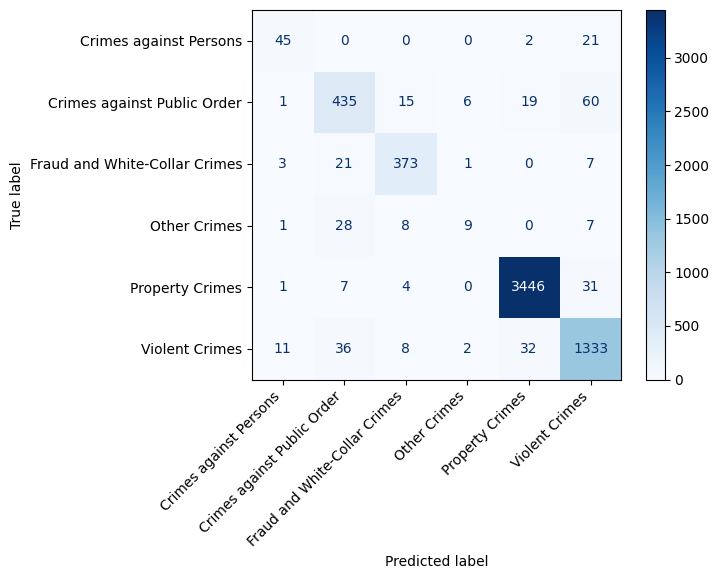

In [123]:
cm = confusion_matrix(y_val,y_pred_xgb)
plt.figure(figsize = (15,12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Crimes against Persons', 'Crimes against Public Order',
 'Fraud and White-Collar Crimes', 'Other Crimes' ,'Property Crimes',
 'Violent Crimes'])  # classes is an array of your class labels
disp.plot(cmap=plt.cm.Blues) 
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.show()

# Comparisons between Models

In [124]:
data = {
    'Model': ["rfc", "xgb1", "lgbm", "gbc", "xgb2"],
    'Precision': [
        [0.71, 0.81, 0.88, 1.00, 0.95, 0.83],# rfc
        [0.71, 0.84, 0.91, 0.50, 0.98, 0.90],# xgb1
        [0.68, 0.80, 0.90, 1.00, 0.99, 0.90],# lgbm
        [0.78, 0.87, 0.91, 0.36, 0.96, 0.85],# gbc
        [0.73, 0.83, 0.91, 0.50, 0.98, 0.91] # xgb2
    ],
    'Recall': [
        [0.54, 0.55, 0.91, 0.06, 0.98, 0.90],# rfc
        [0.66, 0.80, 0.92, 0.15, 0.99, 0.93],# xgb1
        [0.56, 0.79, 0.92, 0.13, 0.99, 0.93],# lgbm
        [0.59, 0.69, 0.88, 0.08, 0.99, 0.89],# gbc
        [0.66, 0.81, 0.92, 0.17, 0.99, 0.94]  # xgb2
    ],
    'F1 Score': [
        [0.62, 0.66, 0.89, 0.11, 0.97, 0.87], # rfc
        [0.69, 0.82, 0.92, 0.23, 0.98, 0.92], # xgb1
        [0.61, 0.80, 0.91, 0.23, 0.99, 0.91], # lgbm
        [0.64, 0.77, 0.90, 0.12, 0.97, 0.87], # gbc
        [0.69, 0.82, 0.92, 0.25, 0.99, 0.93]  # xgb2
    ],
    'Classes': [0, 1, 2, 3, 4, 5]
}

df_precision = pd.DataFrame(data['Precision'], index=data['Model'], columns=data['Classes']).T
df_recall = pd.DataFrame(data['Recall'], index=data['Model'], columns=data['Classes']).T
df_f1 = pd.DataFrame(data['F1 Score'], index=data['Model'], columns=data['Classes']).T

df_combined = pd.concat([df_precision, df_recall, df_f1], keys=['Precision', 'Recall', 'F1 Score'])
print(df_combined)

              rfc  xgb1  lgbm   gbc  xgb2
Precision 0  0.71  0.71  0.68  0.78  0.73
          1  0.81  0.84  0.80  0.87  0.83
          2  0.88  0.91  0.90  0.91  0.91
          3  1.00  0.50  1.00  0.36  0.50
          4  0.95  0.98  0.99  0.96  0.98
          5  0.83  0.90  0.90  0.85  0.91
Recall    0  0.54  0.66  0.56  0.59  0.66
          1  0.55  0.80  0.79  0.69  0.81
          2  0.91  0.92  0.92  0.88  0.92
          3  0.06  0.15  0.13  0.08  0.17
          4  0.98  0.99  0.99  0.99  0.99
          5  0.90  0.93  0.93  0.89  0.94
F1 Score  0  0.62  0.69  0.61  0.64  0.69
          1  0.66  0.82  0.80  0.77  0.82
          2  0.89  0.92  0.91  0.90  0.92
          3  0.11  0.23  0.23  0.12  0.25
          4  0.97  0.98  0.99  0.97  0.99
          5  0.87  0.92  0.91  0.87  0.93


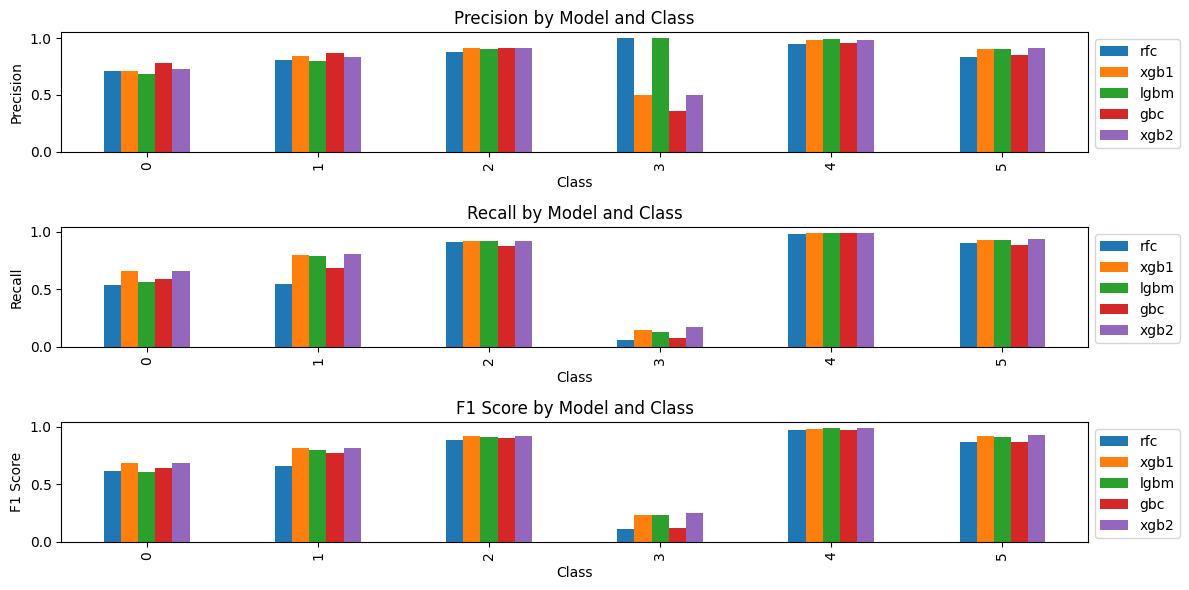

In [125]:
# Plotting
plt.figure(figsize=(18, 12))
metrics = ['Precision', 'Recall', 'F1 Score']
for i, metric in enumerate(metrics):
    plt.subplot(3, 1, i + 1)
    df_metric = df_combined.loc[metric]
    df_metric.plot(kind='bar', figsize=(12, 6), ax=plt.gca())
    plt.title(f'{metric} by Model and Class')
    plt.xlabel('Class')
    plt.ylabel(metric)
    plt.legend(bbox_to_anchor = (1,1), loc ='upper left')

plt.tight_layout()
plt.show()

All models perform well on the majority class with very high precision. lgbm has the highest precision of 0.99. Same goes with recall, all models achieve perfect recall of 0.99 for the majority class, meaning they identify almost all instances of this class correctly.

The F1 scores are all very high, with lgbm and xgb3 having the highest F1 score of 0.99. This indicates a strong balance between precision and recall for the majority class. Also suggesting overfitting.

For minority class 3: There is no balance between precision and recall for minority classes, there high misclassification /high number of false positives for the minority class.Recall is very low for all models, with random forest model having the lowest recall (0.06) but slightly recall improved with XGboost hyperparameter tuned 0.17.
F1 scores are very low for the minority class across all models. xgb2 performs the best with an F1 score of 0.25, but the performance is still quite poor.

Further analysis, in order improve recall and f1 score for minority classes I have trying upsampling/downsampling.

In [126]:
#from imblearn.over_sampling import RandomOverSampler
#oversampler = RandomOverSampler(sampling_strategy='auto', random_state=42)
#X_resampled, y_resampled = oversampler.fit_resample(X_train, y_train)


# Test Data preprocessing

In [127]:
#rename, to remove space
test = test.rename(columns = {'Part 1-2': 'Part_1_2'})
dt_t = pd.DataFrame()

dt_t = test[['Date_Occurred', 'Time_Occurred', 'Date_Reported']].copy()
dt_t['Date_Occurred'] = pd.to_datetime(dt_t['Date_Occurred'], format='%m/%d/%Y %I:%M:%S %p')
dt_t['Date_Reported'] = pd.to_datetime(dt_t['Date_Reported'], format='%m/%d/%Y %I:%M:%S %p')

dt_t['Day_Occurred'] = dt_t['Date_Occurred'].dt.day
dt_t['Month_Occurred'] = dt_t['Date_Occurred'].dt.month
dt_t['Dayofweek_O'] = dt_t['Date_Occurred'].dt.weekday

dt_t['Time_Occurred'] = dt_t['Time_Occurred'].astype(int).astype(str).str.zfill(4)
dt_t['Hour_Occurred'] = dt_t['Time_Occurred'].str[:2].astype(int)

In [128]:
dt_t['Delayed_Reporting']= (dt_t['Date_Reported']- dt_t['Date_Occurred']).dt.days
dt_t['Delayed_Reporting_Binned'] = pd.cut(dt_t['Delayed_Reporting'],
                                                        bins=[-np.inf, 1, 30, 183, np.inf],
                                                        labels=['Immediate', 'Withinamonth', 'Within6months', 'Morethan6months'])

In [129]:
dt_t['Time_of_Day'] = dt_t['Hour_Occurred'].apply(categorize_time)

In [130]:
dt_t.head()

,Date_Occurred,Time_Occurred,Date_Reported,Day_Occurred,Month_Occurred,Dayofweek_O,Hour_Occurred,Delayed_Reporting,Delayed_Reporting_Binned,Time_of_Day
0,2020-03-03,2000,2020-03-03,3,3,1,20,0,Immediate,Night
1,2020-04-25,1700,2020-06-01,25,4,5,17,37,Within6months,Evening
2,2020-08-27,0900,2020-08-28,27,8,3,9,1,Immediate,Morning
3,2020-12-03,2200,2020-12-23,3,12,3,22,20,Withinamonth,Night
4,2020-08-29,0130,2020-08-30,29,8,5,1,1,Immediate,Early Morning


In [131]:
dt_t = dt_t.drop(['Date_Occurred', 'Time_Occurred', 'Date_Reported', 'Day_Occurred', 'Delayed_Reporting'], axis = 1)
test = pd.concat([test, dt_t], axis =1)

In [132]:
location_address_t = pd.DataFrame(test['Location'])

location_address_t['Street_Type'] = location_address_t['Location'].apply(extract_street_type)

location_address_t['Street_Type_bin'] = location_address_t['Street_Type'].apply(
    lambda x: x if x in main_street_types else ('Others' if x is not None else None)
)

test = pd.concat([test, location_address_t[['Street_Type_bin']]], axis =1)

In [133]:
test['Victim_Sex'] = test['Victim_Sex'].replace('H', np.nan)

In [134]:
test['Victim_Age']=test['Victim_Age'].replace([-2,-1,0], np.nan)

In [135]:
#Binning least frequent together
test['Victim_Descent'] = test['Victim_Descent'].apply(
    lambda x: x if x in Top_Victim_Descent else ('Others' if not pd.isna(x) else np.nan)
)


In [136]:
test['Premise_Code'] = test['Premise_Code'].apply(
    lambda x: x if x in Top_Premise else ('Others' if not pd.isna(x) else np.nan)
)

test['Premise_Code'] = test['Premise_Code'].astype(str)

In [137]:
test['Reporting_District_no'] = test['Reporting_District_no'].astype(int)
test['Part_1_2'] = test['Part_1_2'].astype(int)

In [138]:
test['cluster_label'] = kmeans.predict(test[['Latitude', 'Longitude']])

In [139]:
test.columns

Index(['Location', 'Cross_Street', 'Latitude', 'Longitude', 'Date_Reported',
       'Date_Occurred', 'Time_Occurred', 'Area_ID', 'Area_Name',
       'Reporting_District_no', 'Part_1_2', 'Modus_Operandi', 'Victim_Age',
       'Victim_Sex', 'Victim_Descent', 'Premise_Code', 'Premise_Description',
       'Weapon_Used_Code', 'Weapon_Description', 'Status',
       'Status_Description', 'Month_Occurred', 'Dayofweek_O', 'Hour_Occurred',
       'Delayed_Reporting_Binned', 'Time_of_Day', 'Street_Type_bin',
       'cluster_label'],
      dtype='object')

In [140]:
test =test.drop(['Location','Latitude', 'Longitude', 'Cross_Street','Date_Reported',
       'Date_Occurred', 'Time_Occurred', 'Area_ID', 'Area_Name','Premise_Description',
       'Weapon_Used_Code', 'Weapon_Description','Status_Description',
        'Hour_Occurred'] , axis =1)

In [141]:
warnings.filterwarnings("ignore")
xgb_pipeline_f = Pipeline([('preprocessing',union),
                         ('feature_selection',SelectKBest(score_func = mutual_info_classif, k=1000)),
                         ('xgb',XGBClassifier(objective='multi:softmax',num_class=6, seed = 42, 
                                              n_estimators=500,
                                              eta = 0.15, subsample = 0.75,
                                              min_child_weight = 1, max_depth = 10, 
                                              gamma=0.5, colsample_bylevel=0.5, max_delta_step = 3))])
xgb_pipeline.fit(X,y)
y_pred_final = xgb_pipeline.predict(test)

In [142]:
y_pred_labels = le.inverse_transform(y_pred_final)

In [143]:
submission = pd.DataFrame({
    "ID": np.arange(1, 5001),  
    "Crime_Category": y_pred_labels})

# Save to CSV
submission.to_csv('submission.csv', index=False)

In [144]:
import os
print(os.path.abspath('submission.csv'))

/kaggle/working/submission.csv
